In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
##Visualize the timeseries data
## Check first for stationarity of the time series

df = pd.read_csv('group2_interpolated_complete.csv')

df['Month'] = pd.to_datetime(df['Month'])

stations = df['Stations'].unique()
parameters = [col for col in df.columns if col not in ['Month', 'Stations']]

# for station in stations:
#     station_df = df[df['Stations'] == station].sort_values('Month')
    
#     fig, axs = plt.subplots(len(parameters), 1, figsize=(12, 3 * len(parameters)))
#     fig.suptitle(f"Parameter Trends for {station}", fontsize=16, y=1.02)

#     for i, param in enumerate(parameters):
#         ax = axs[i] if len(parameters) > 1 else axs
#         ax.plot(station_df['Month'], station_df[param], marker='o', linestyle='-')
#         ax.set_title(param)
#         ax.set_xlabel('Month')
#         ax.set_ylabel('Value')
#         ax.grid(True)

#     plt.tight_layout()
#     plt.show()




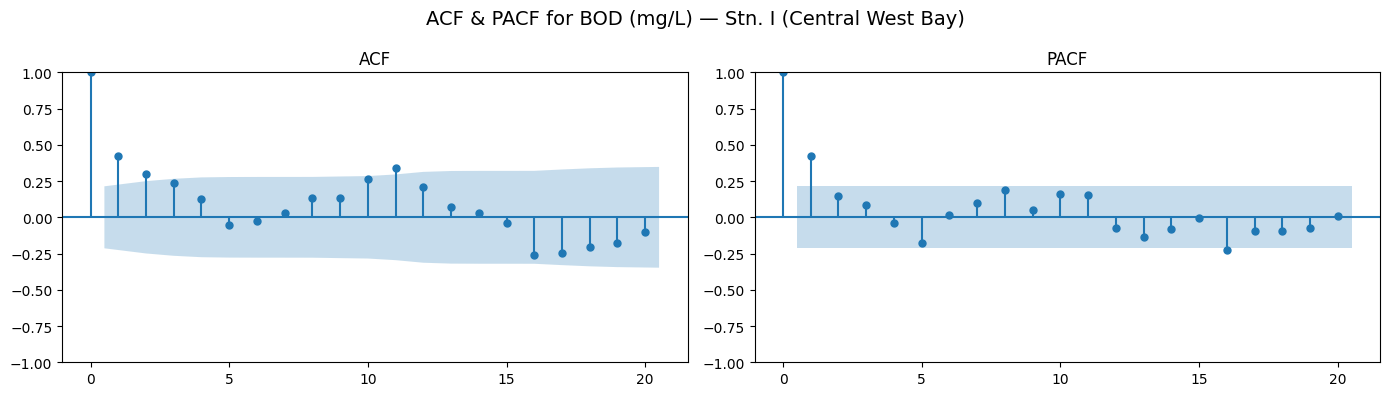

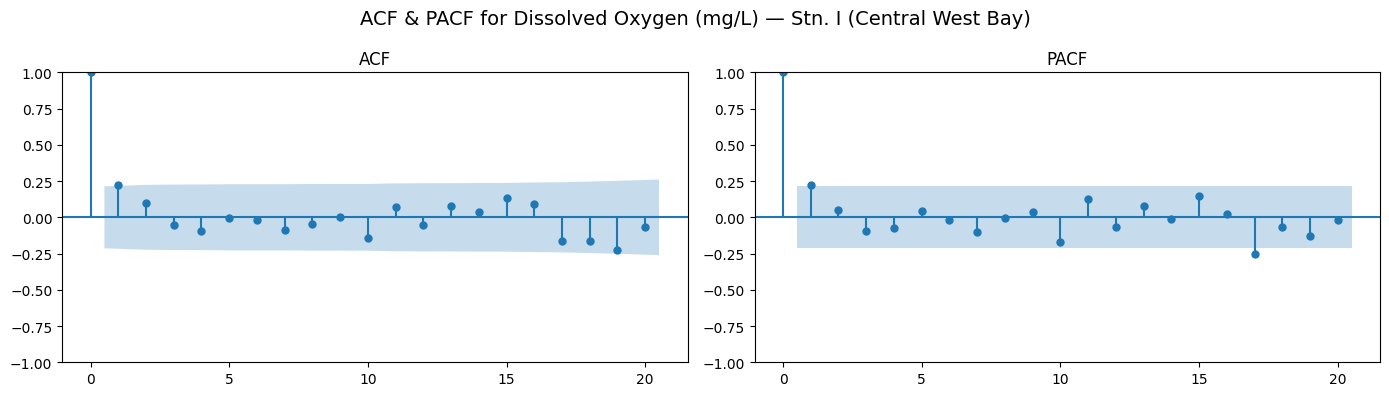

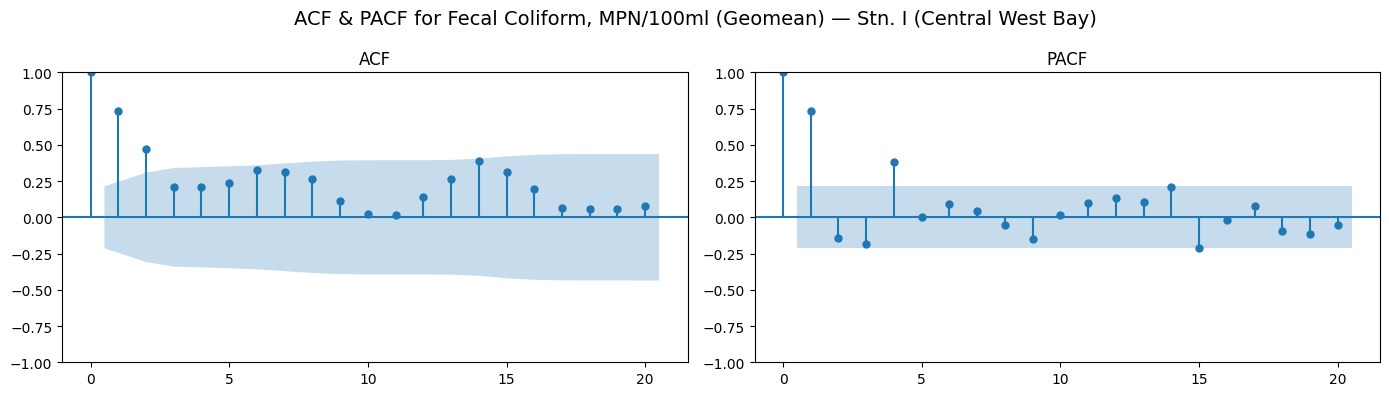

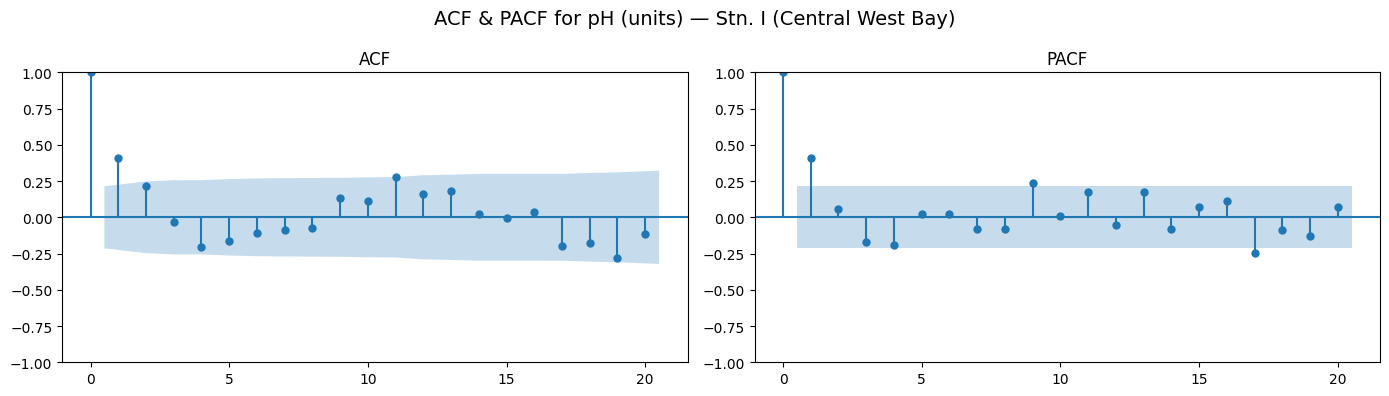

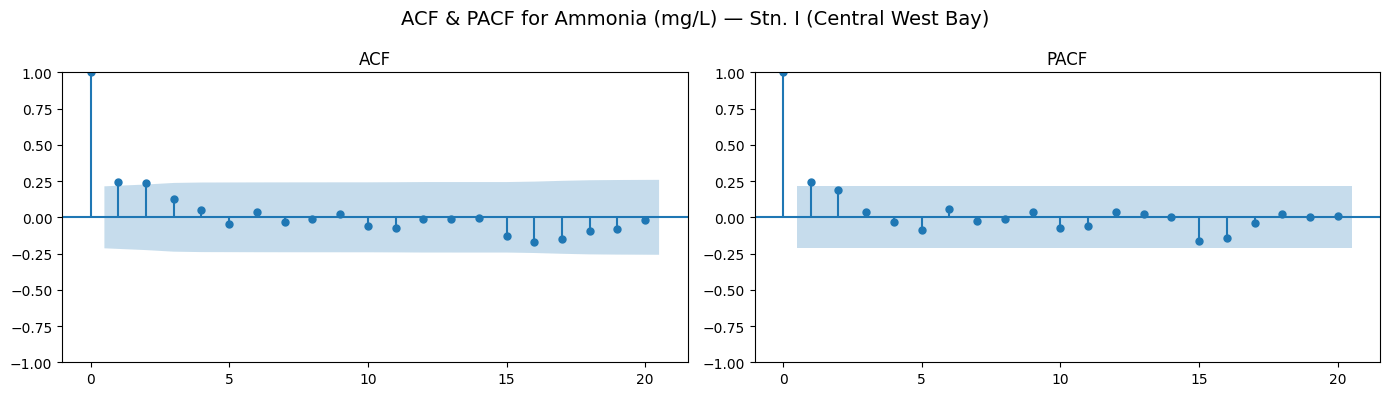

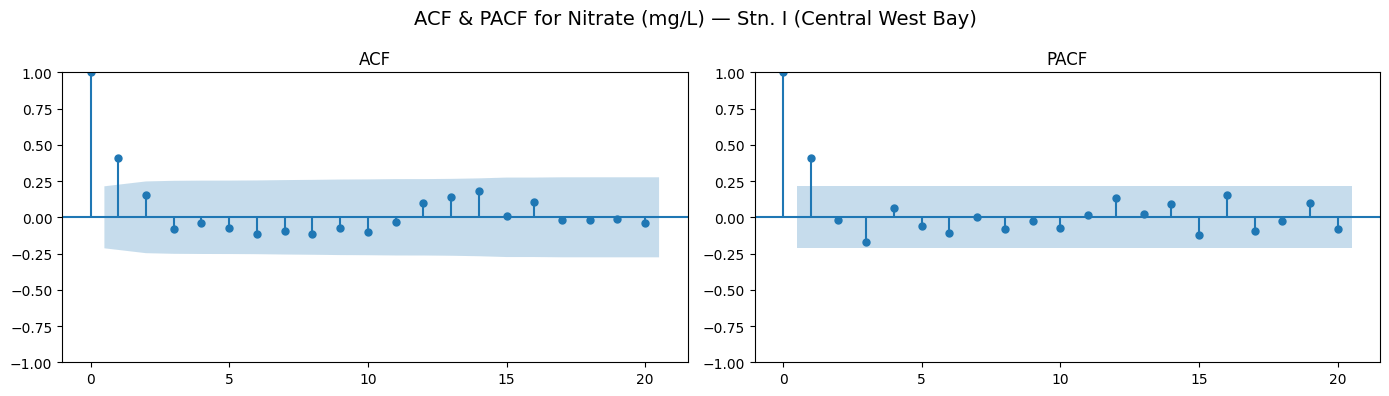

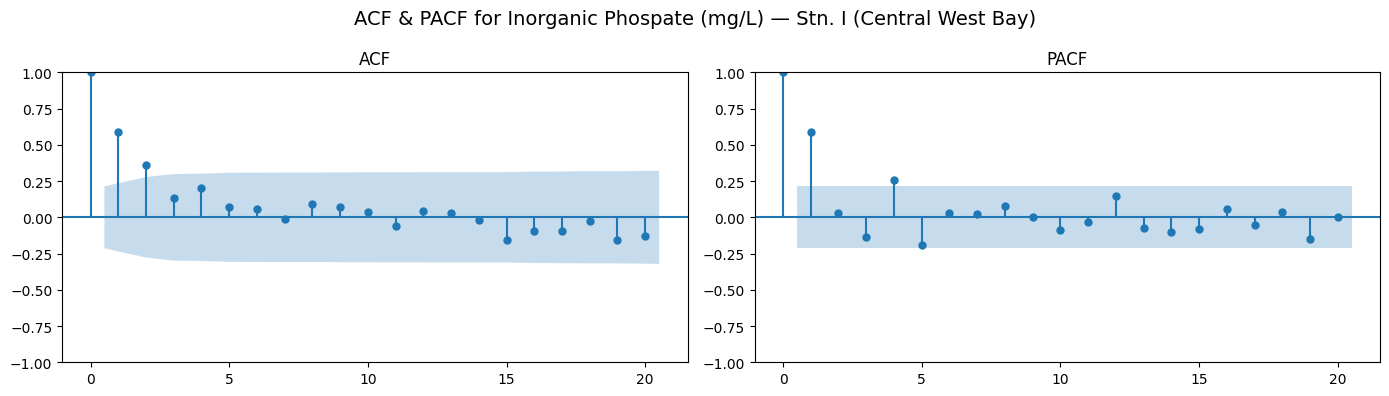

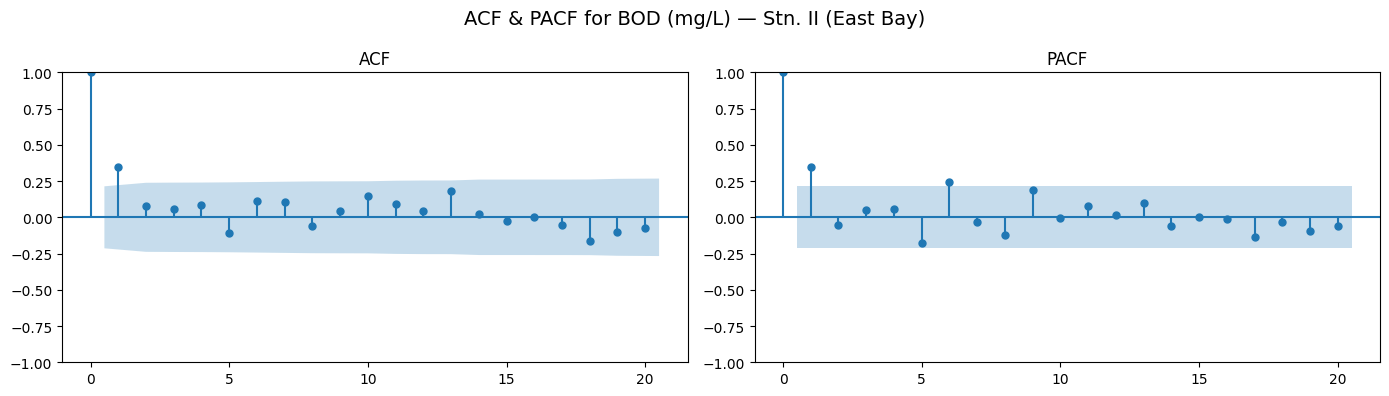

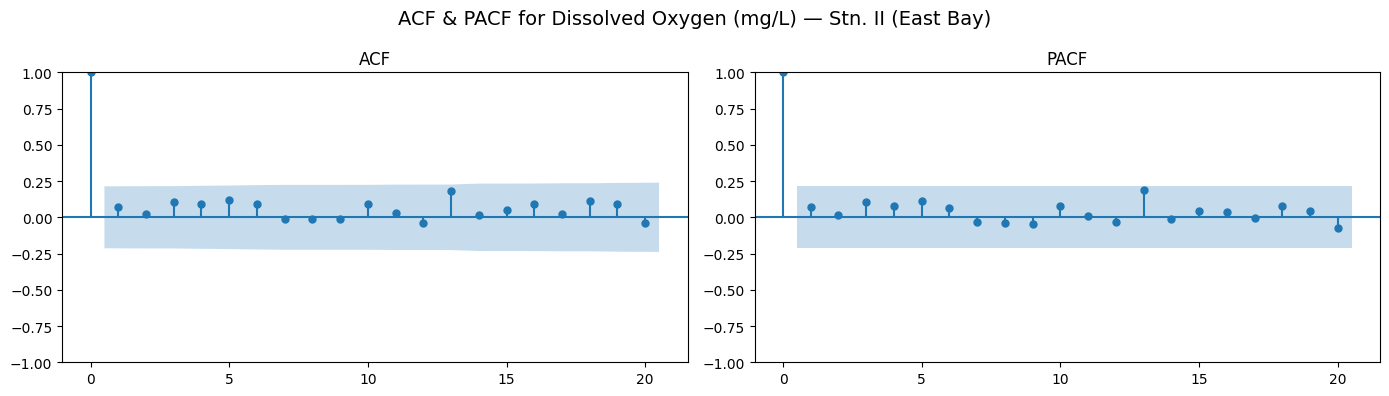

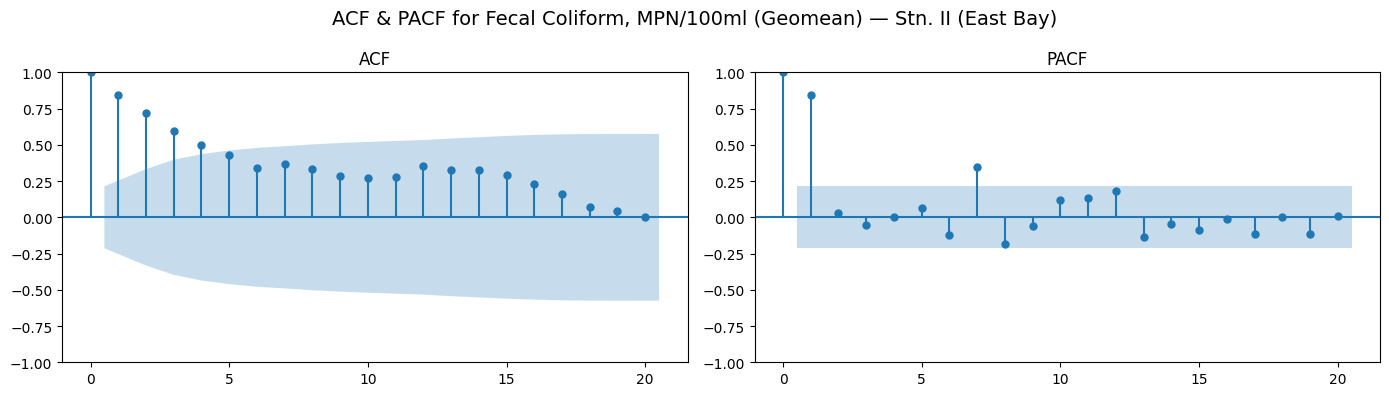

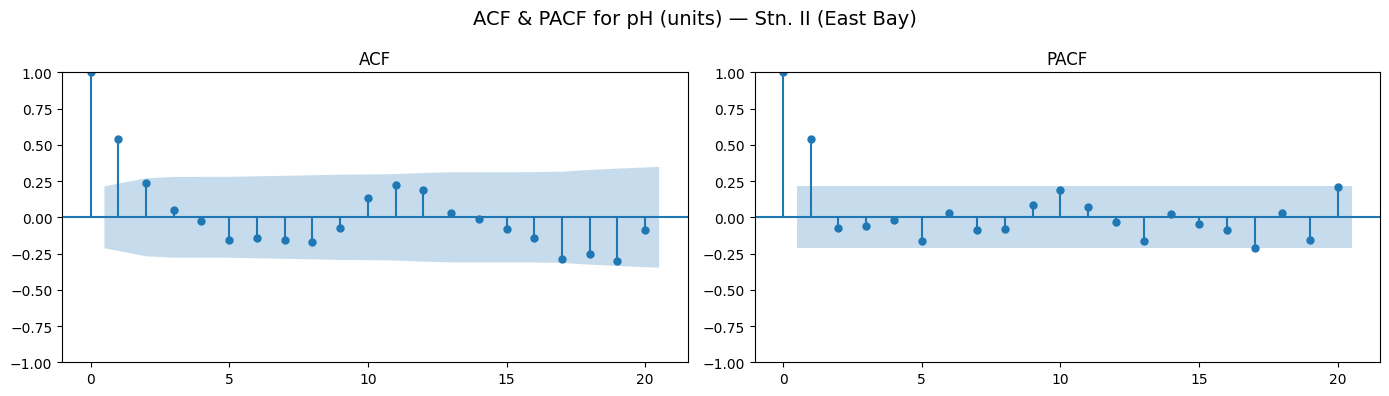

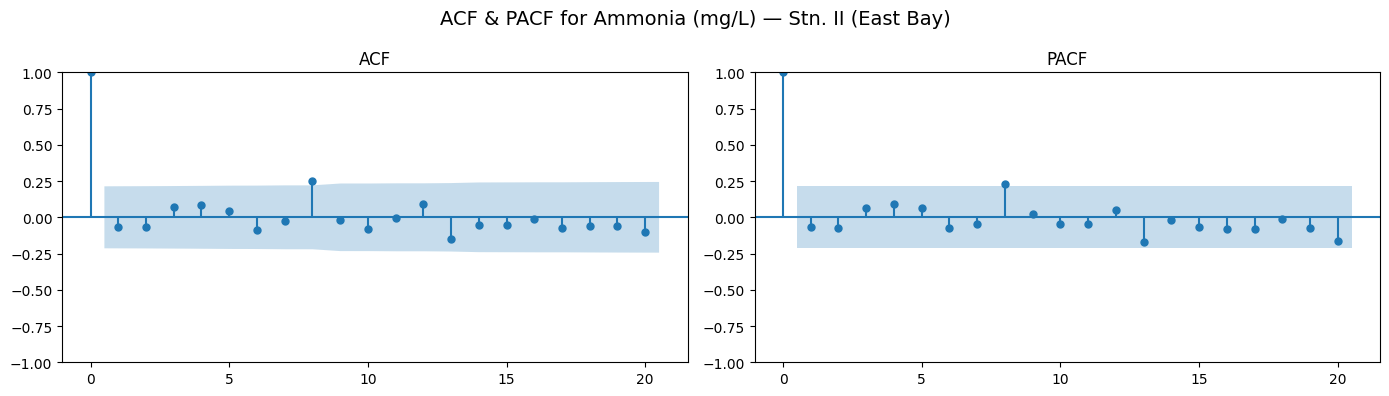

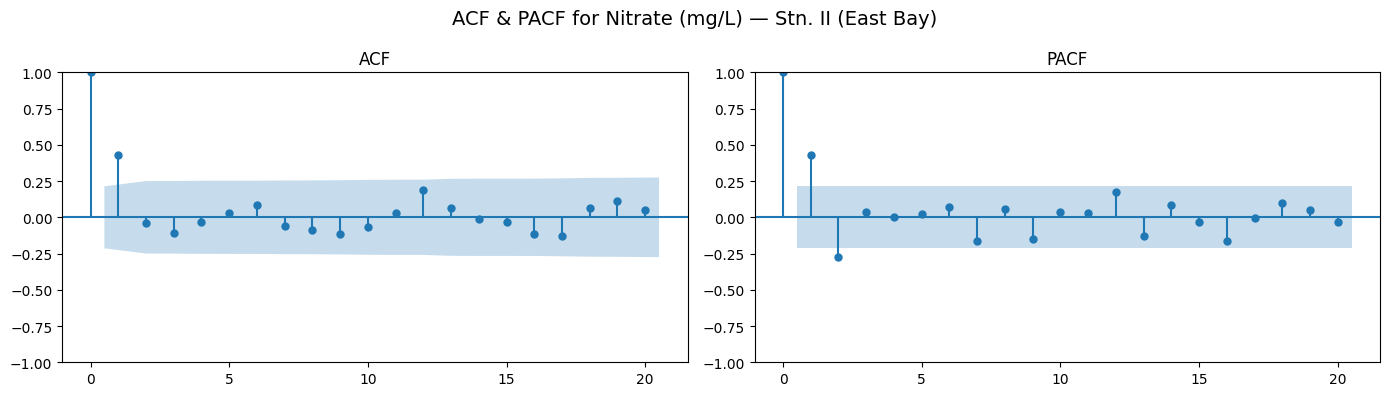

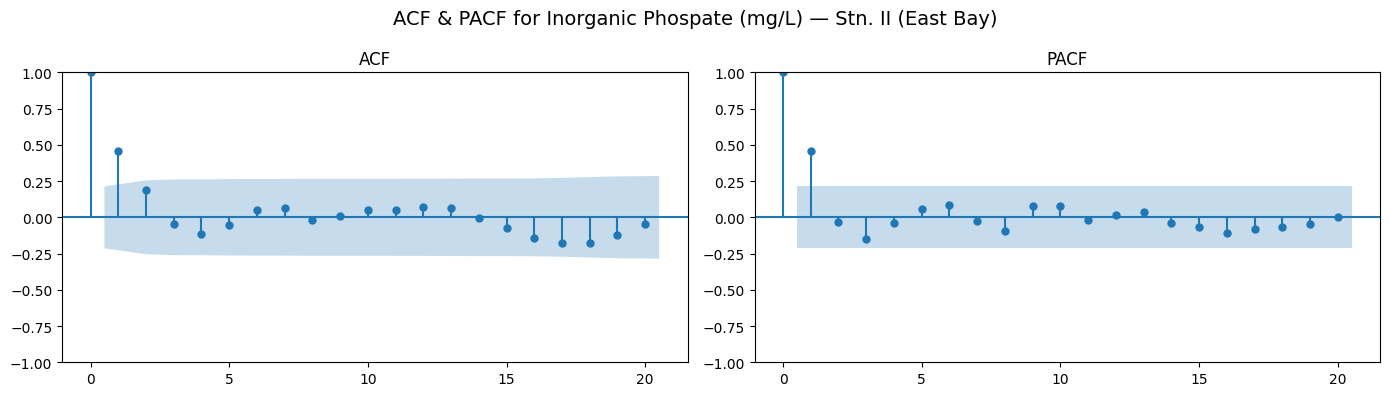

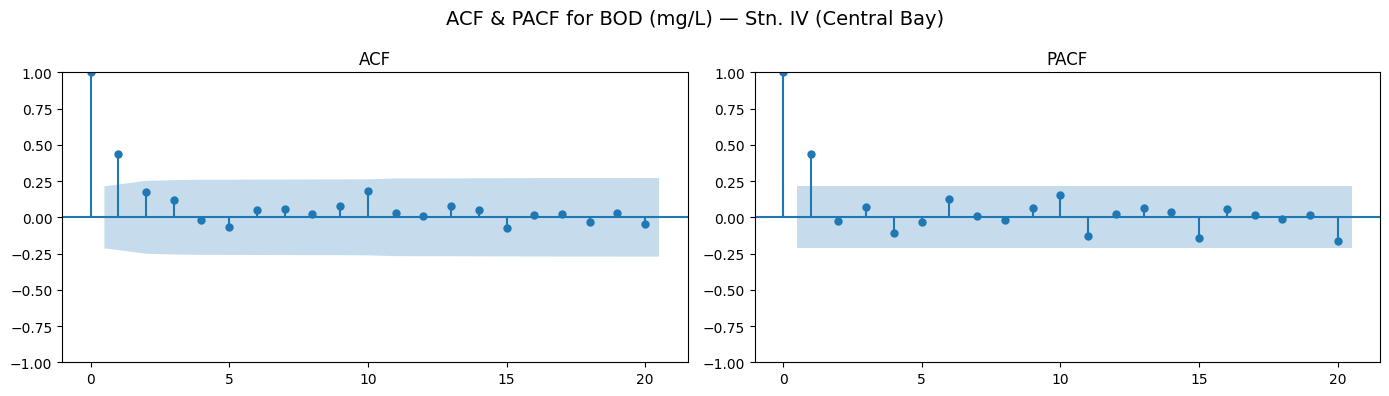

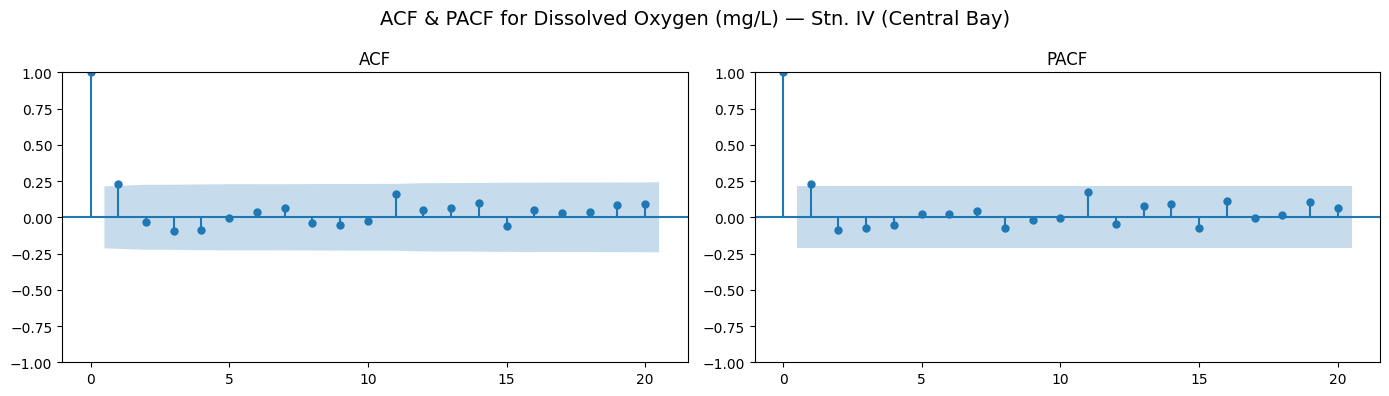

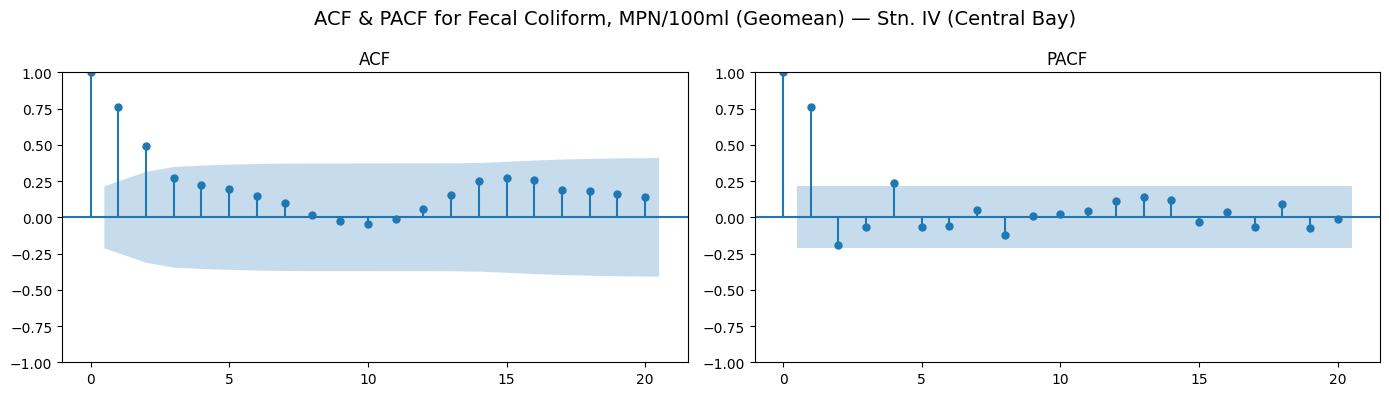

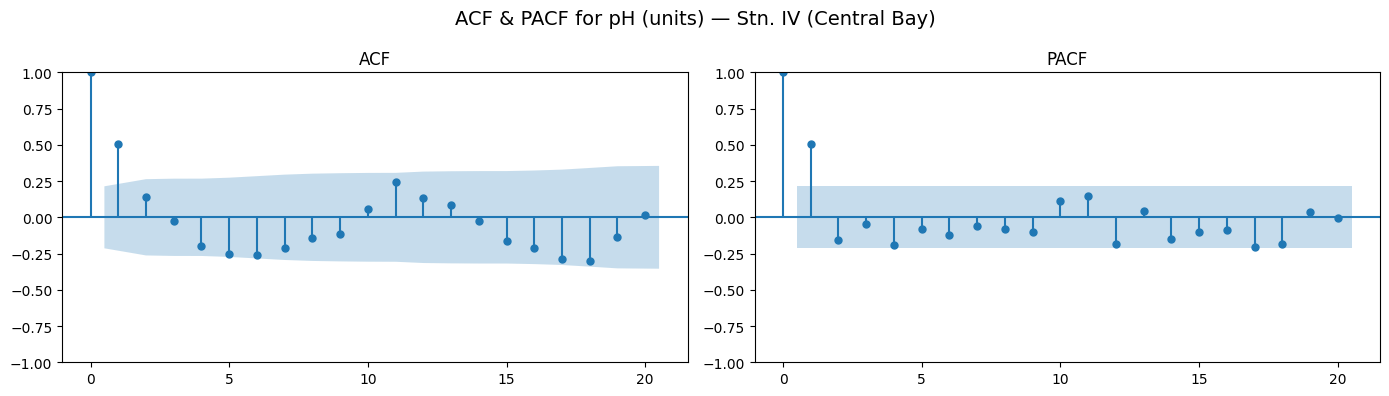

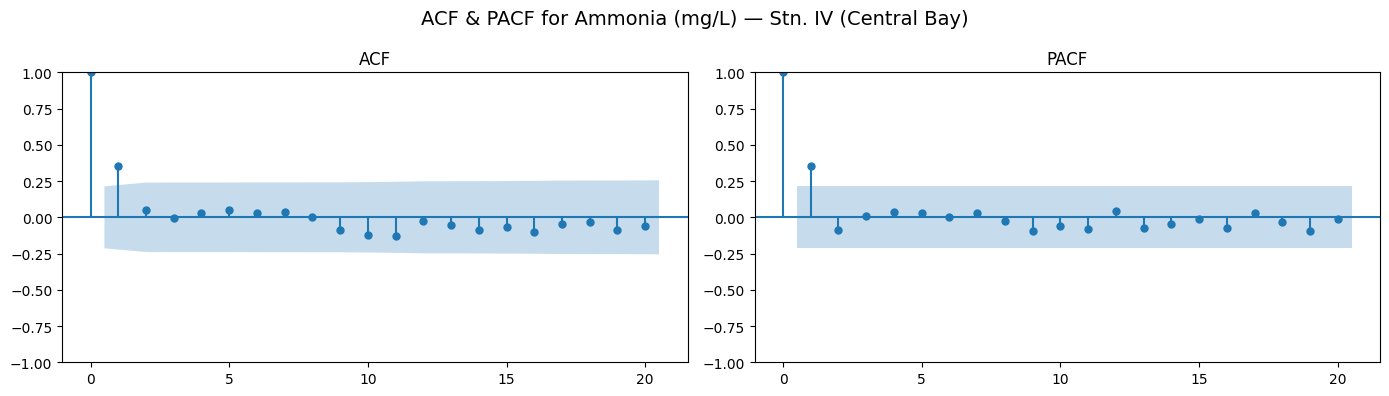

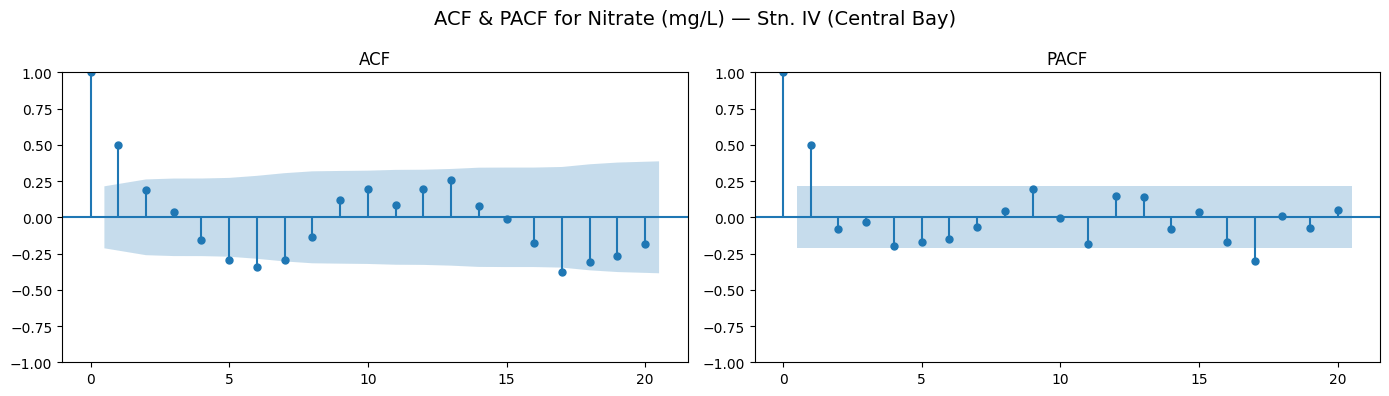

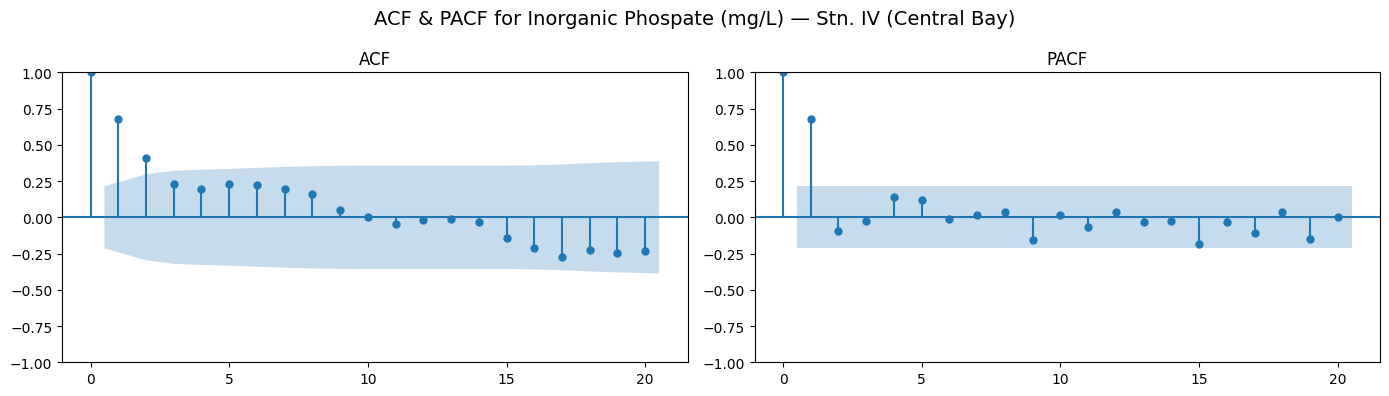

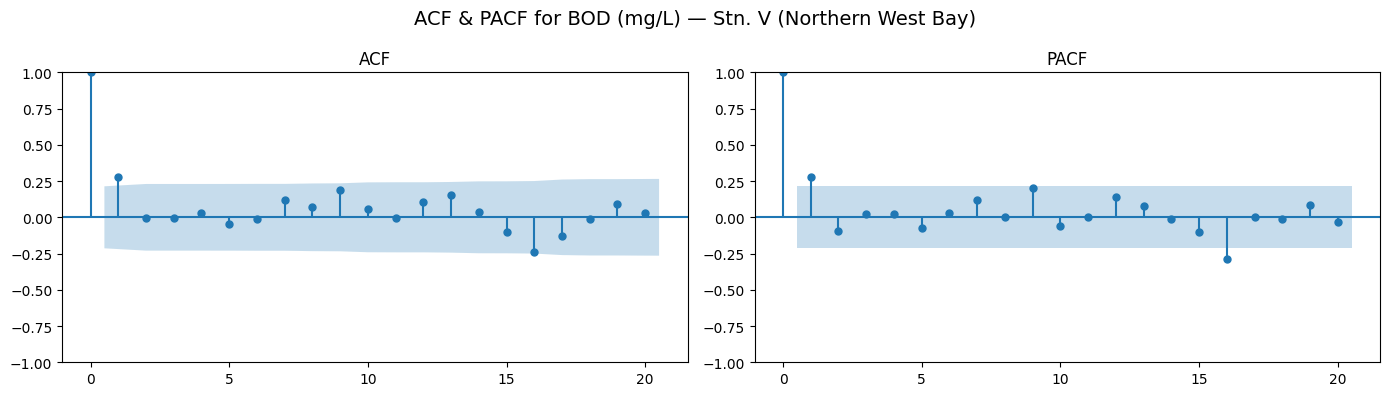

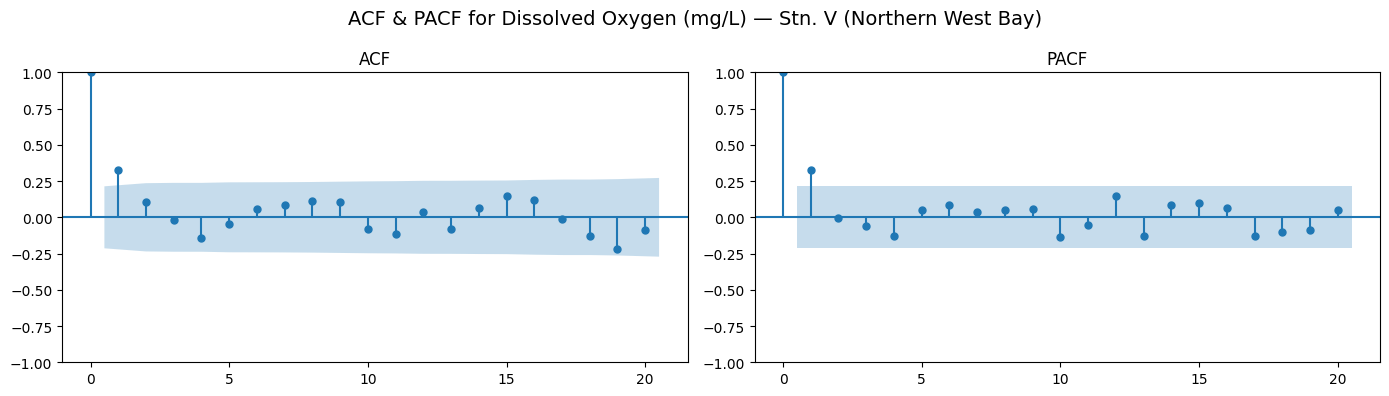

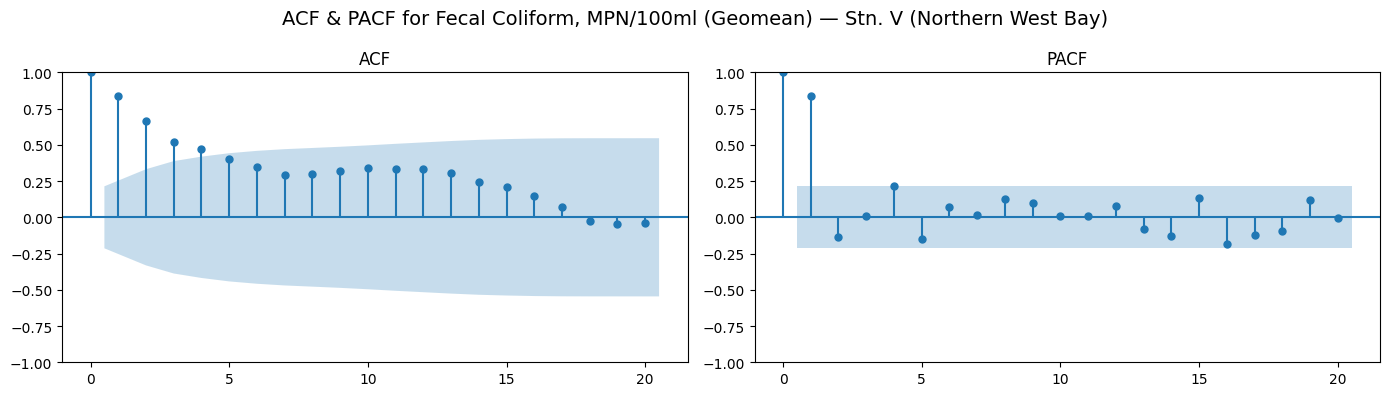

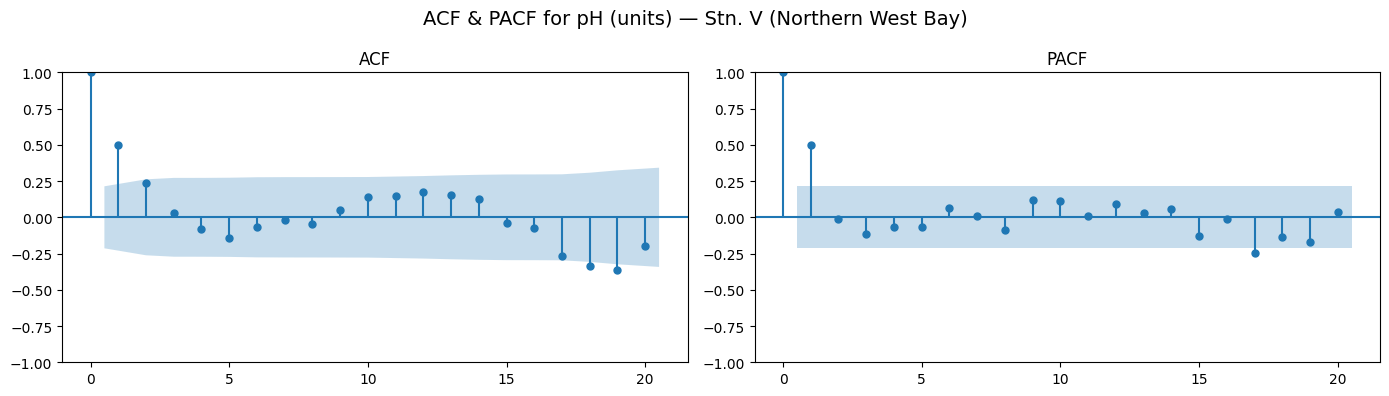

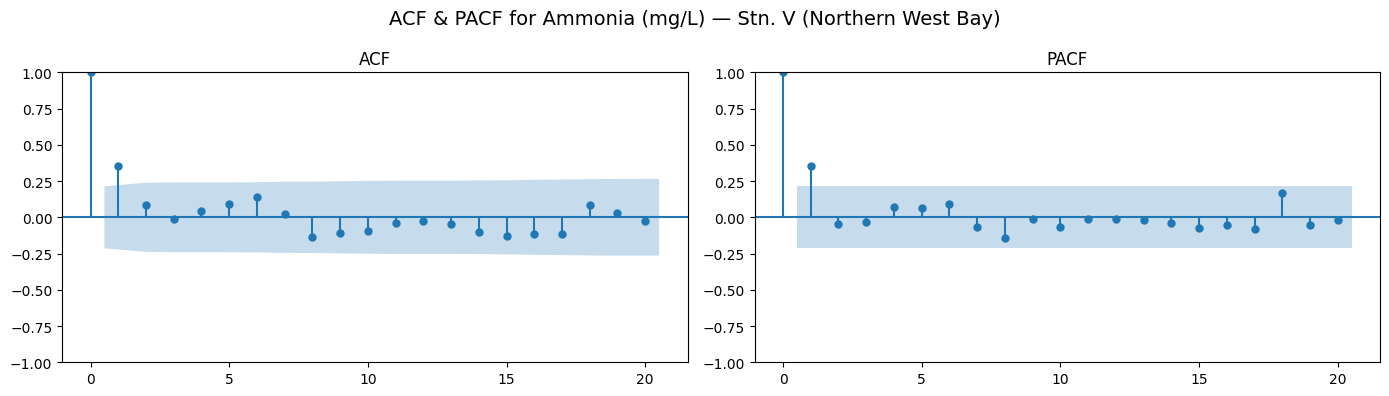

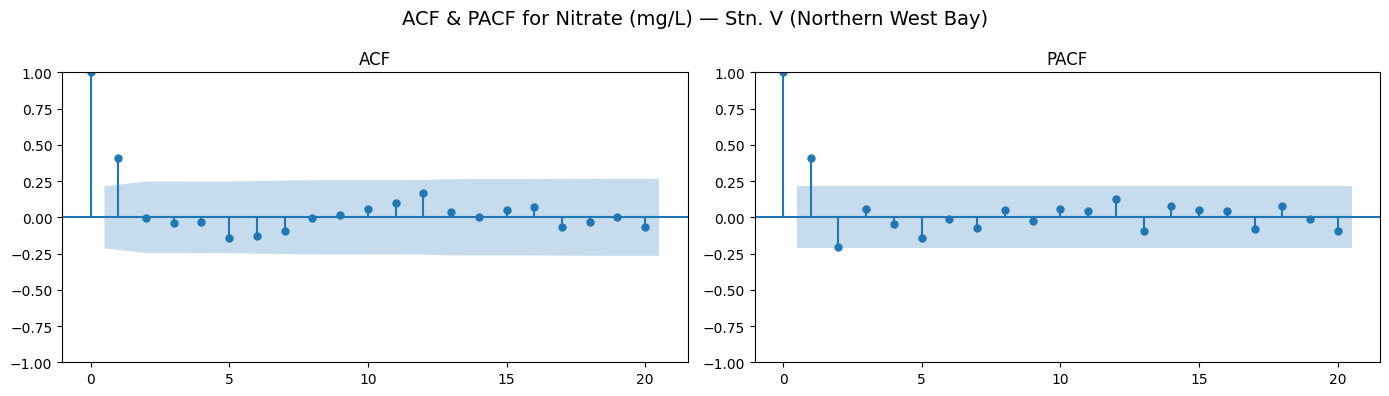

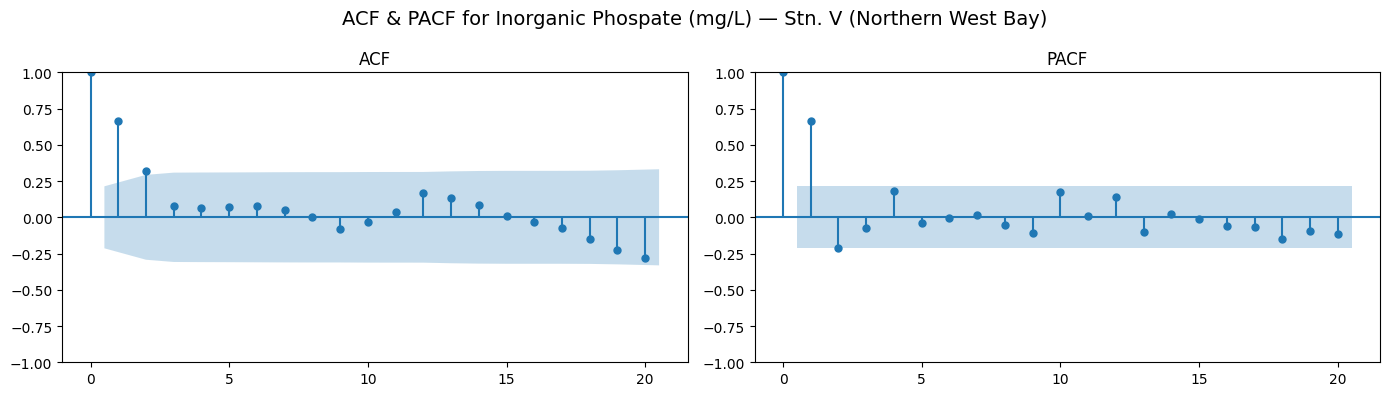

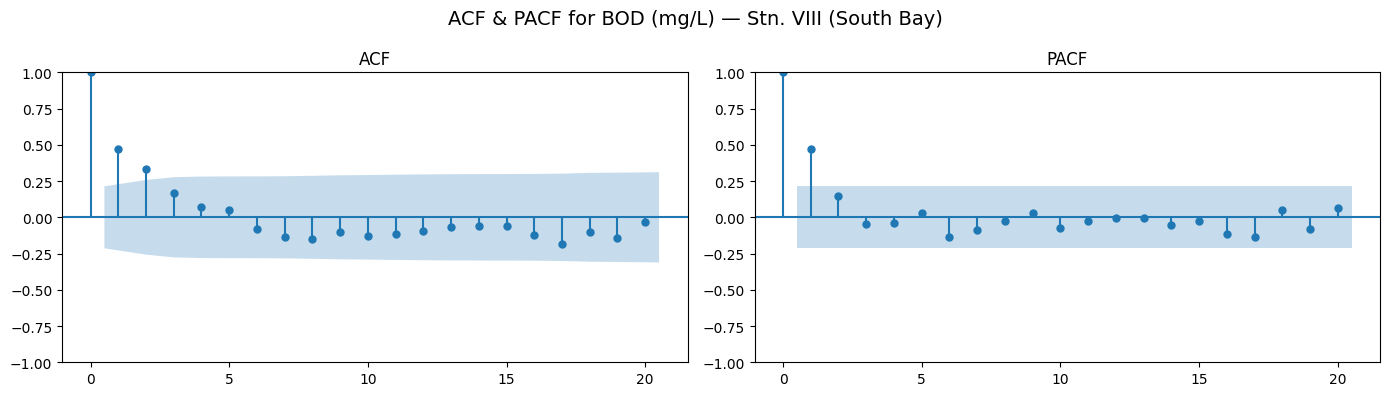

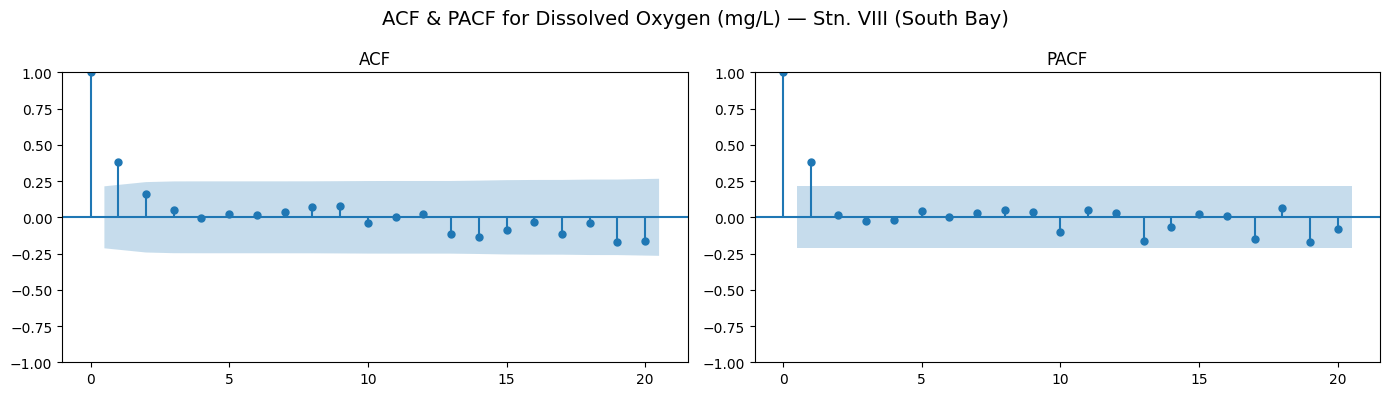

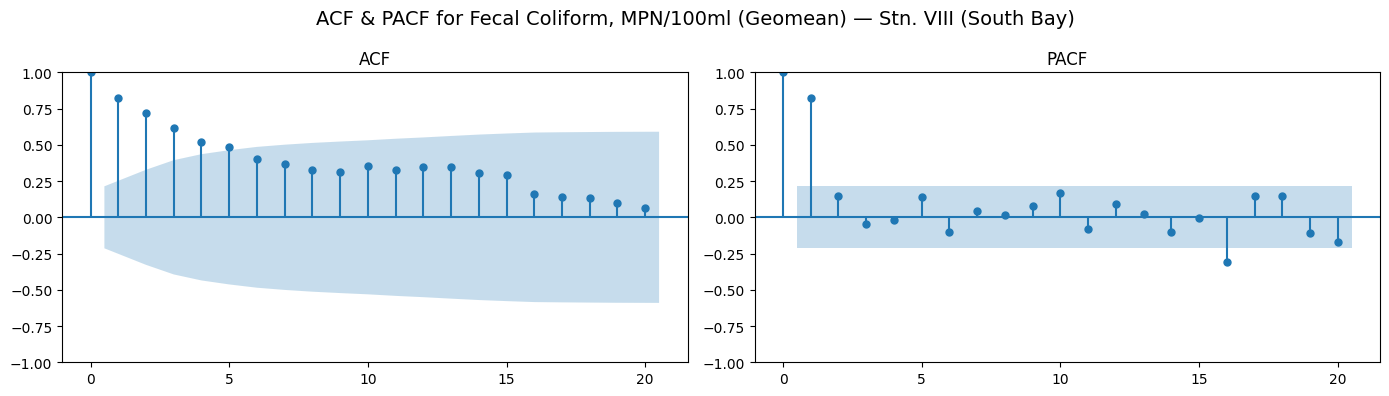

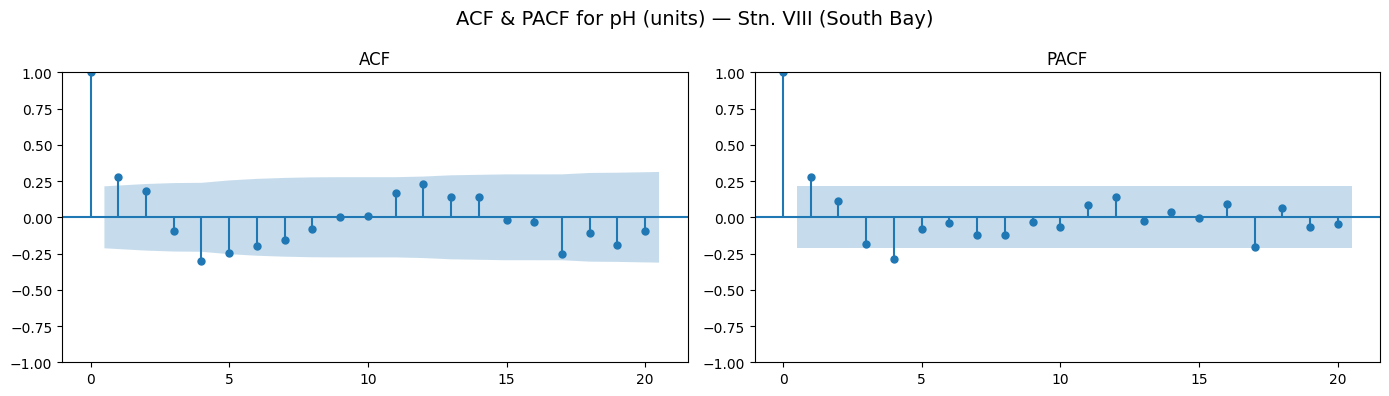

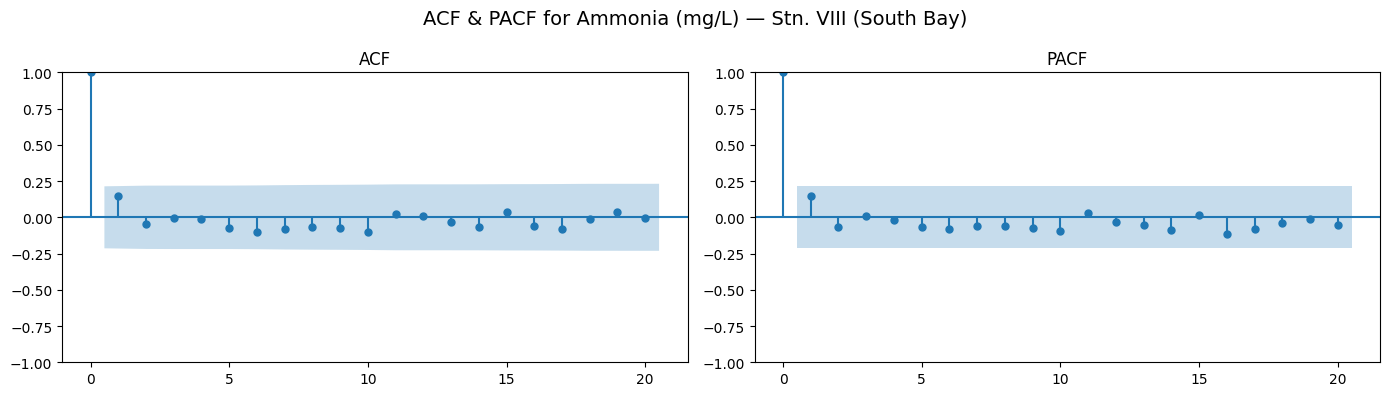

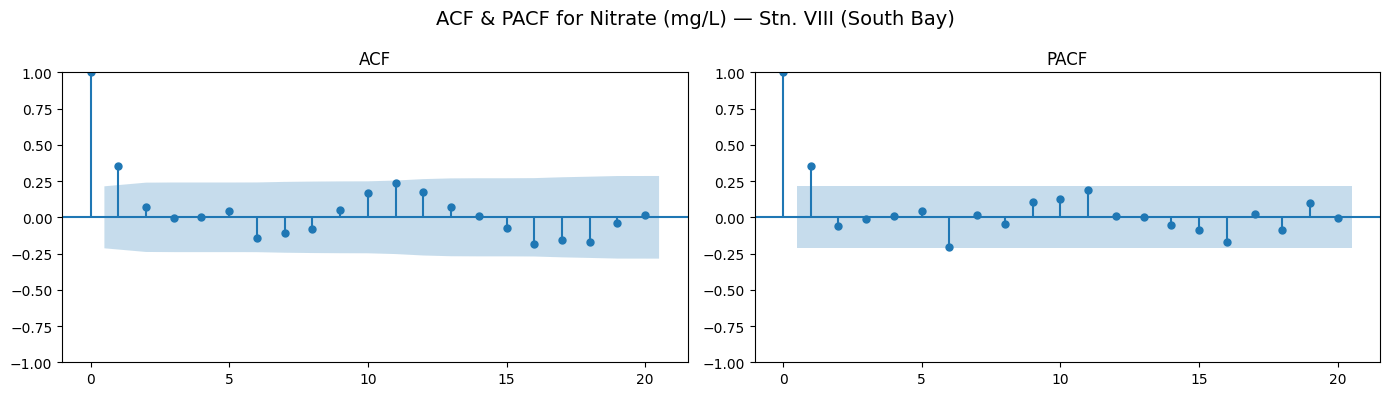

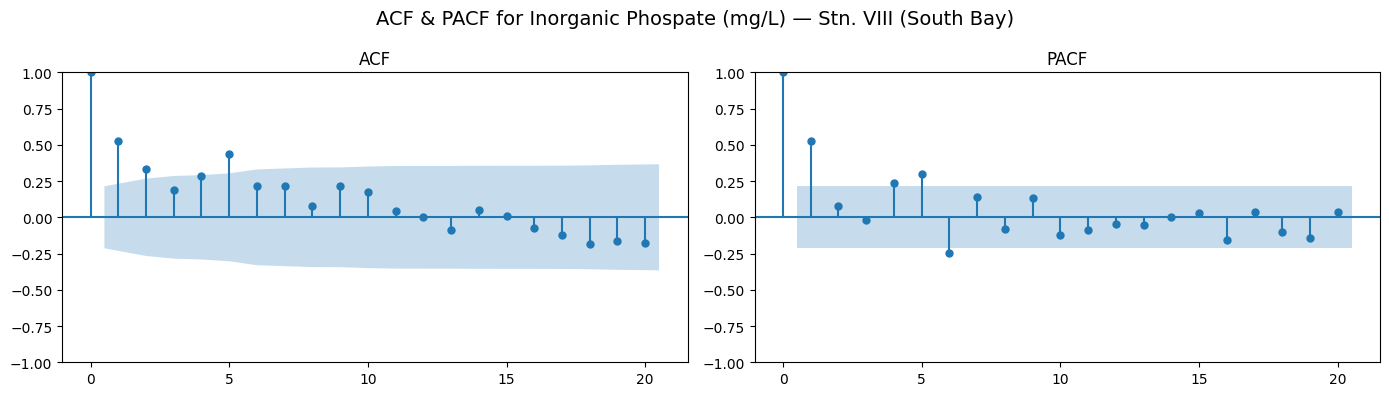

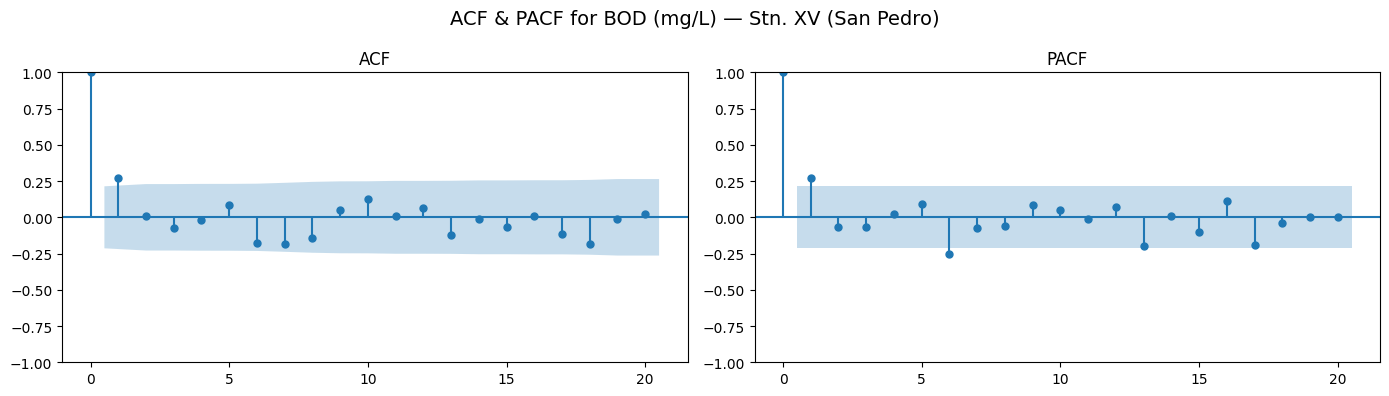

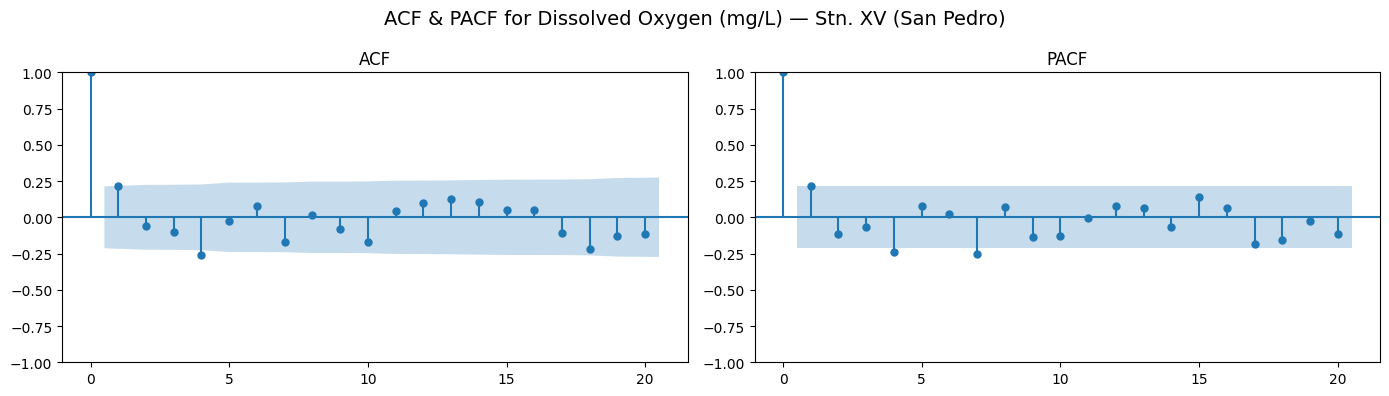

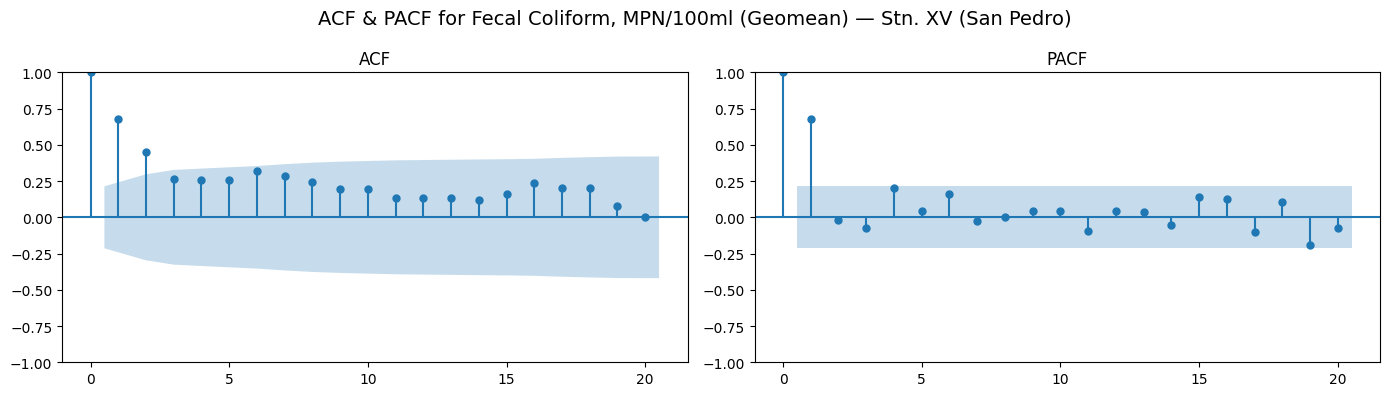

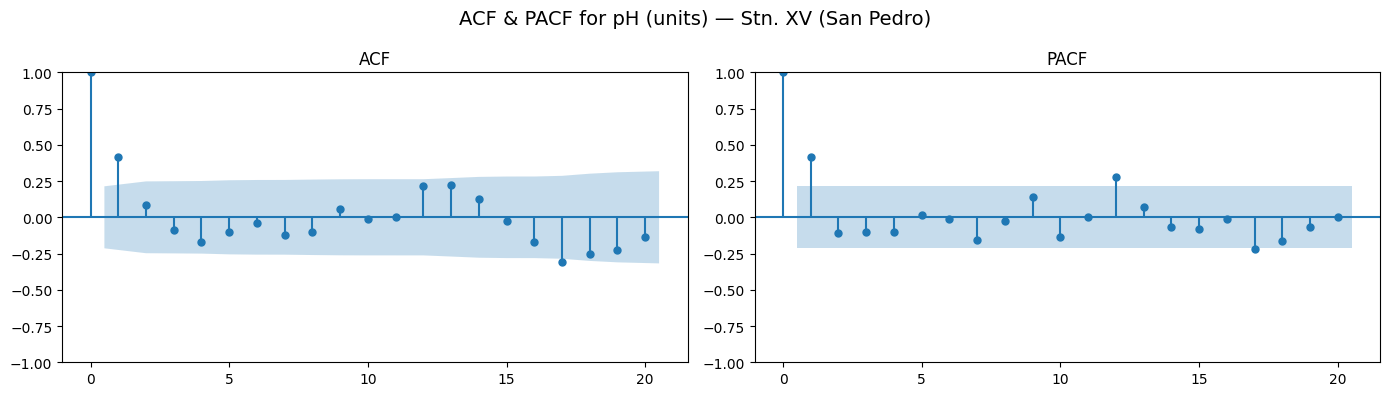

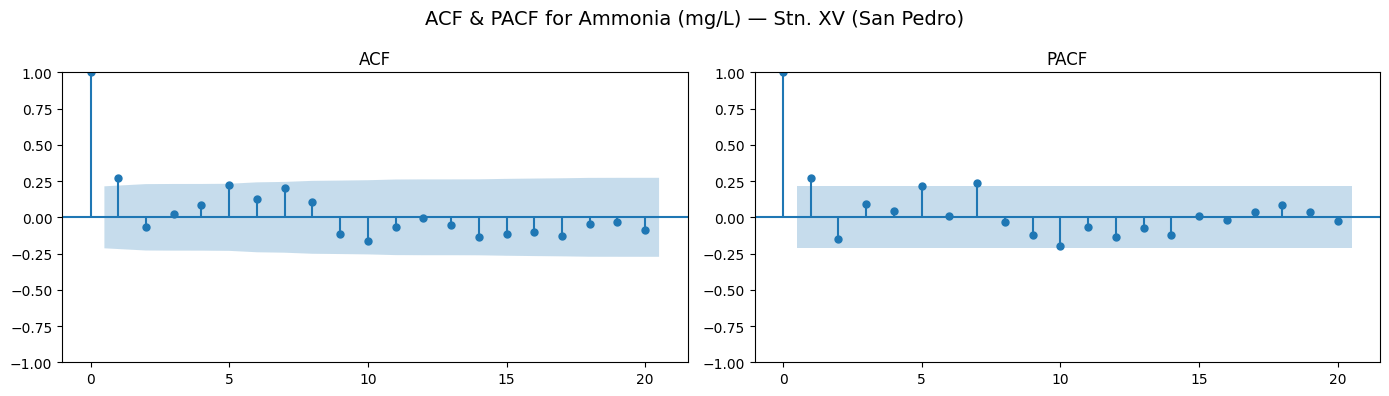

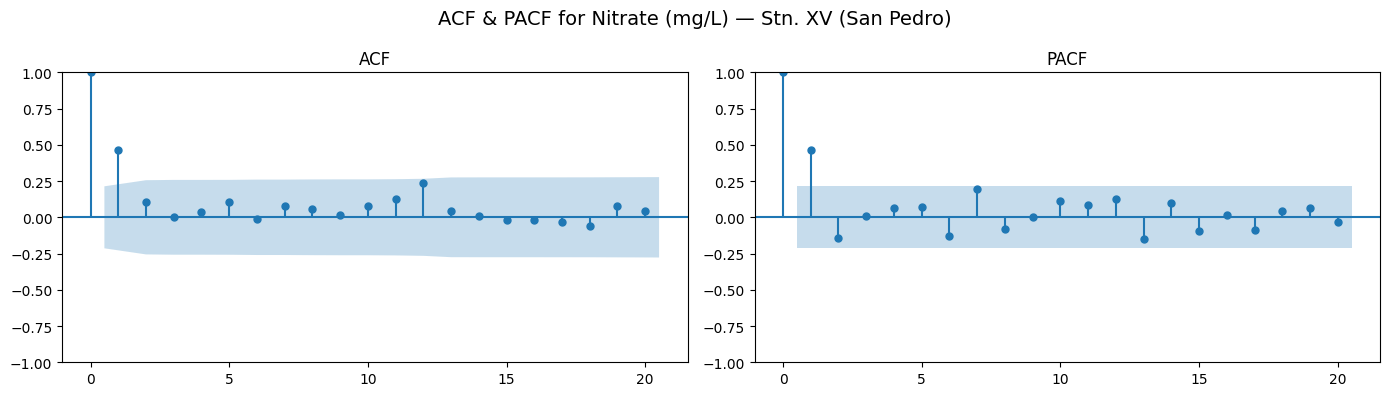

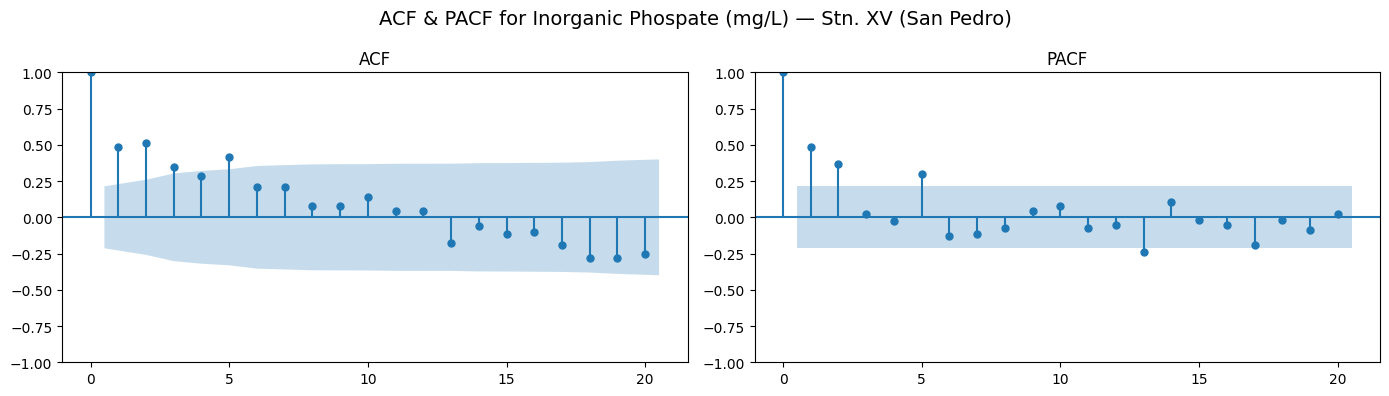

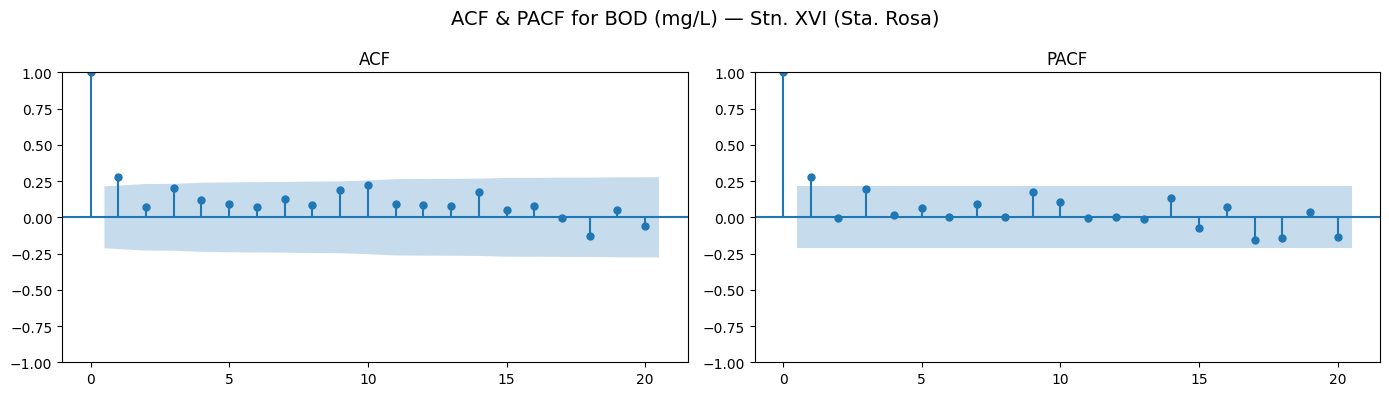

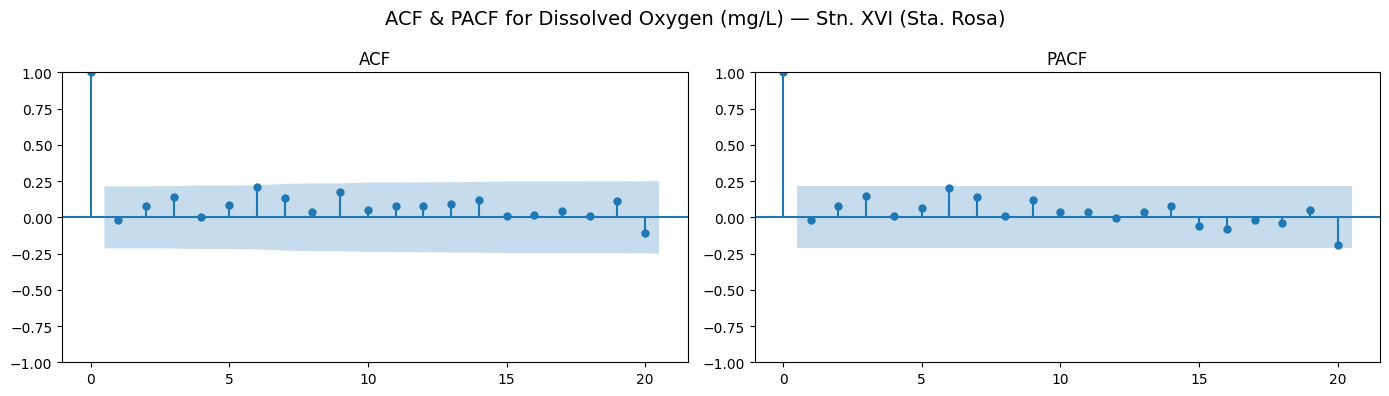

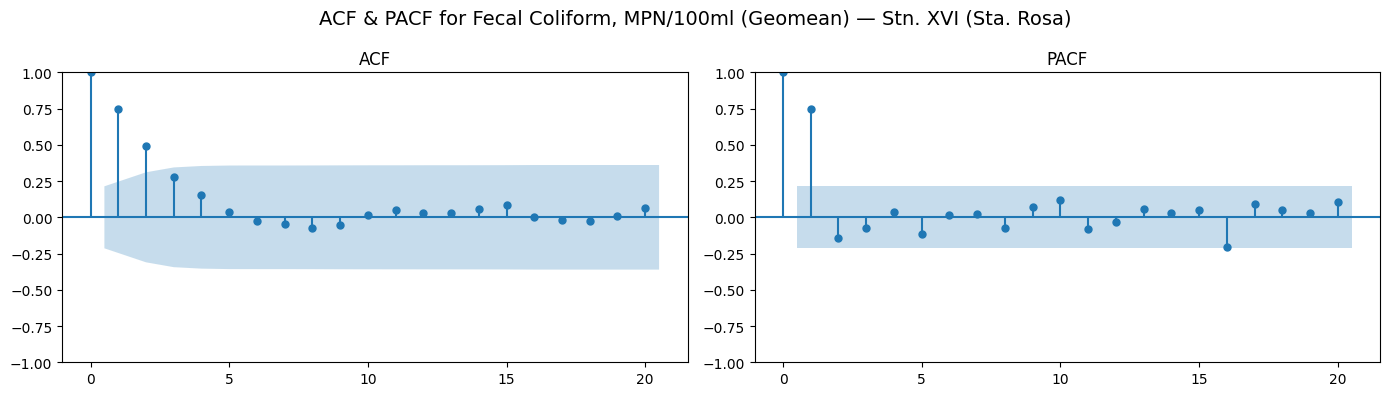

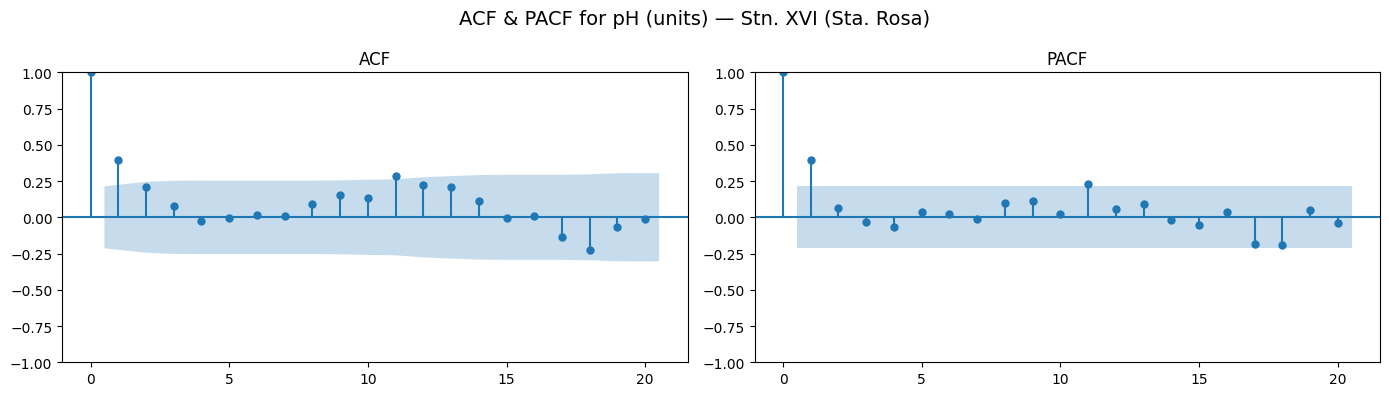

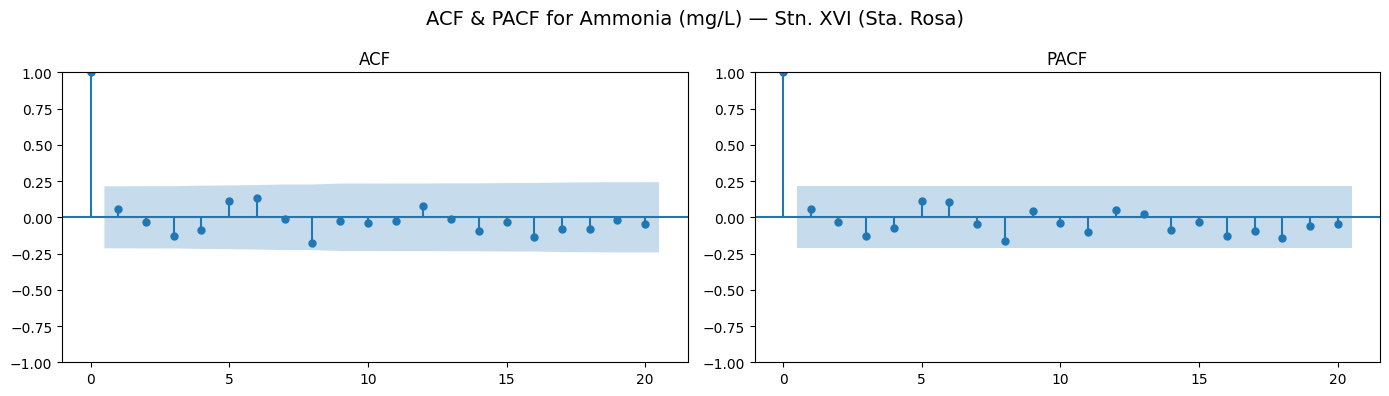

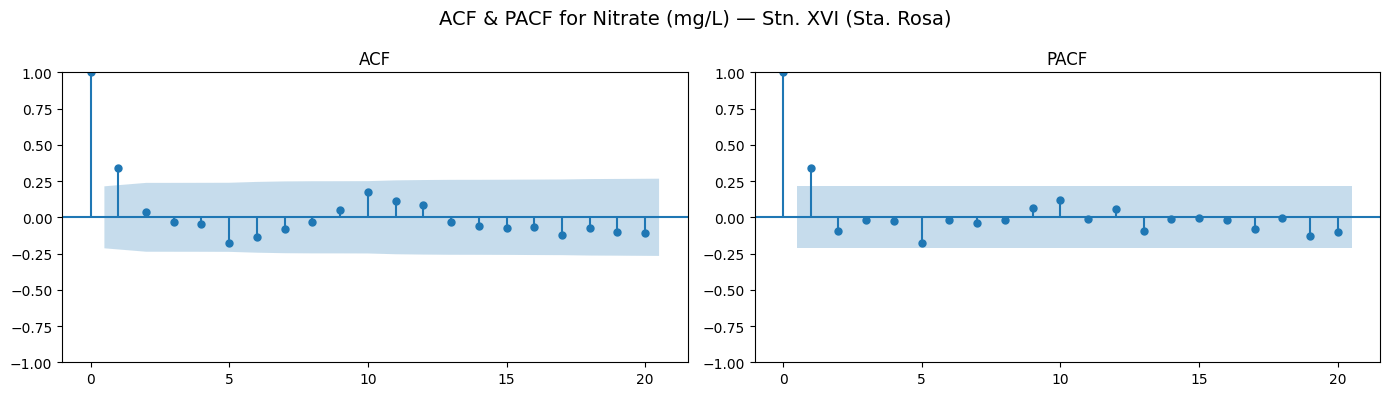

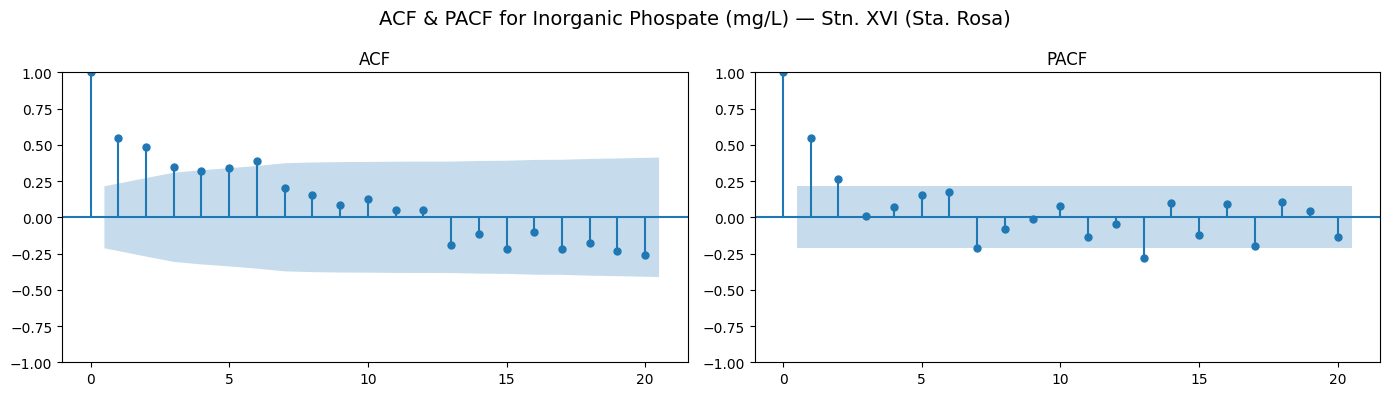

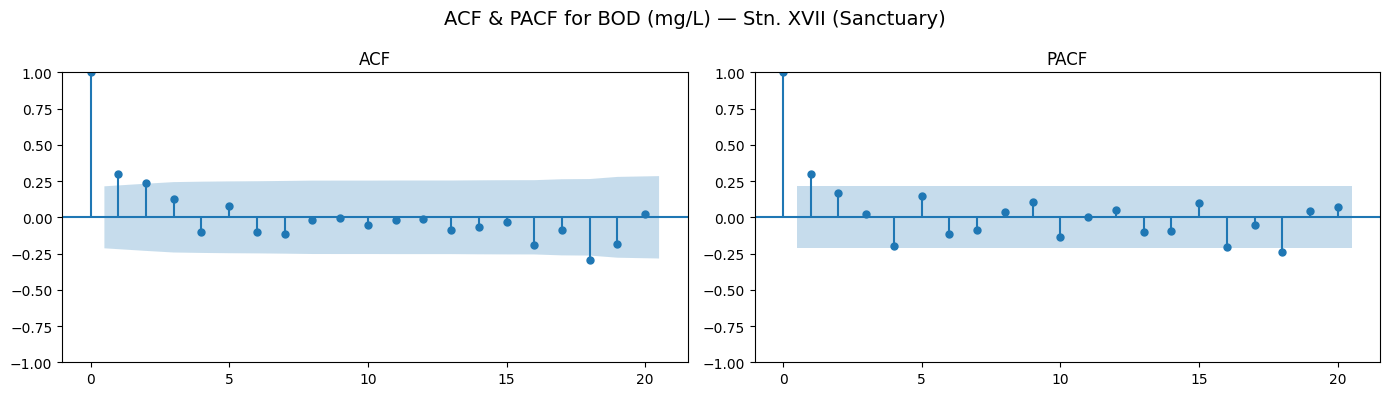

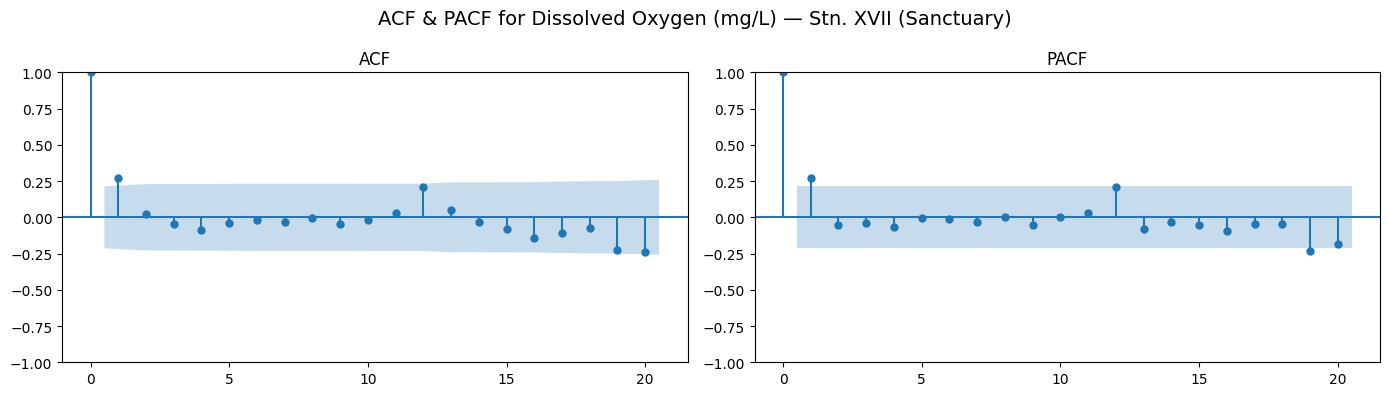

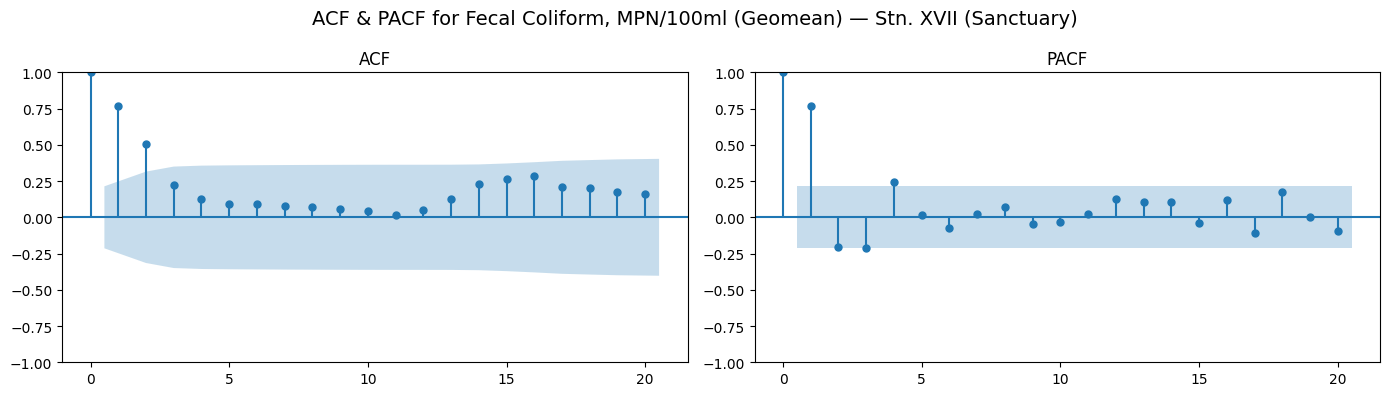

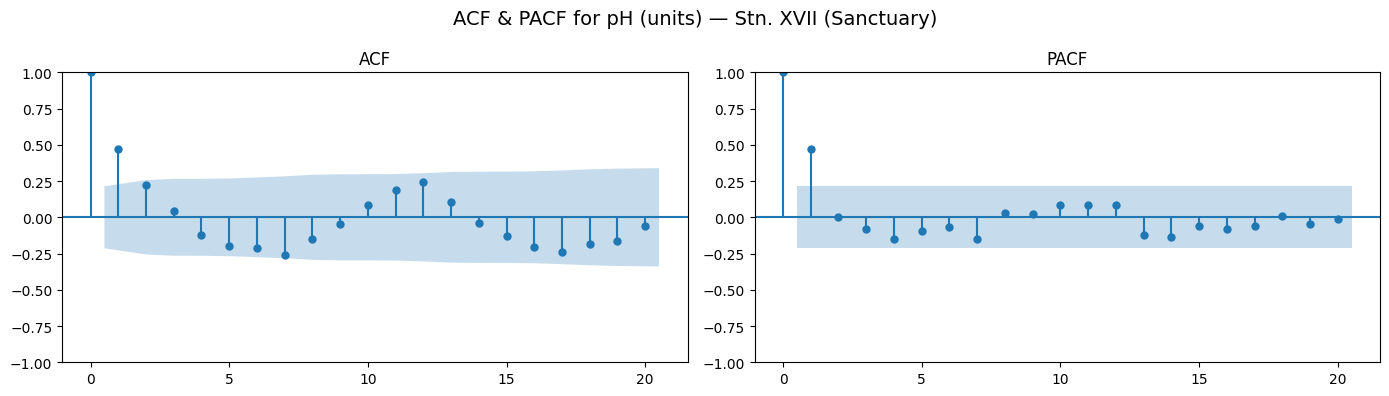

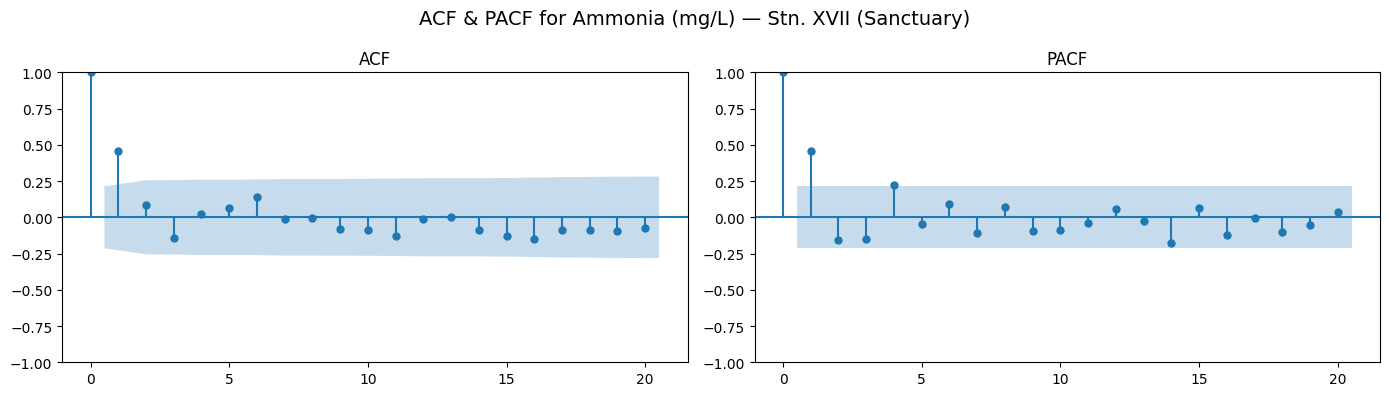

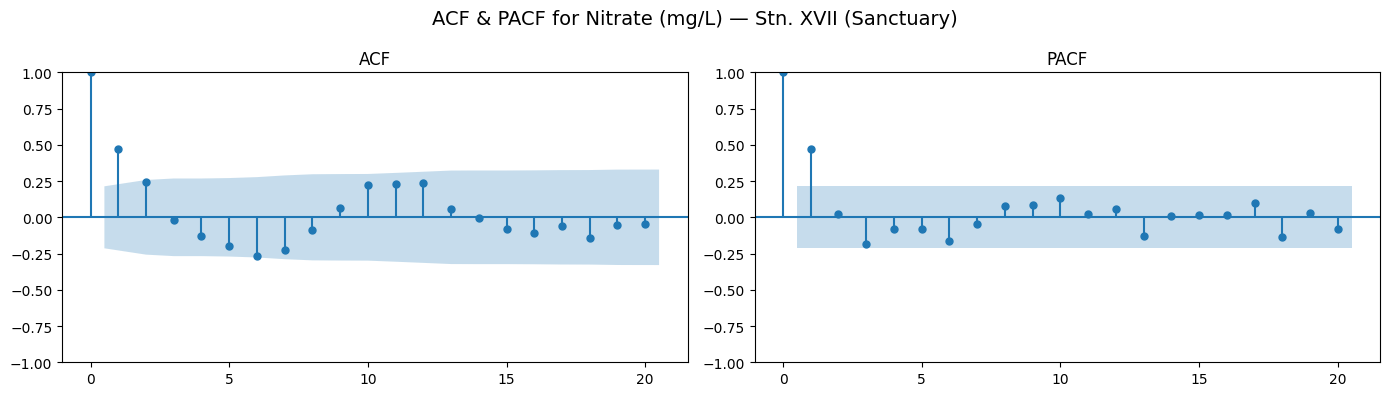

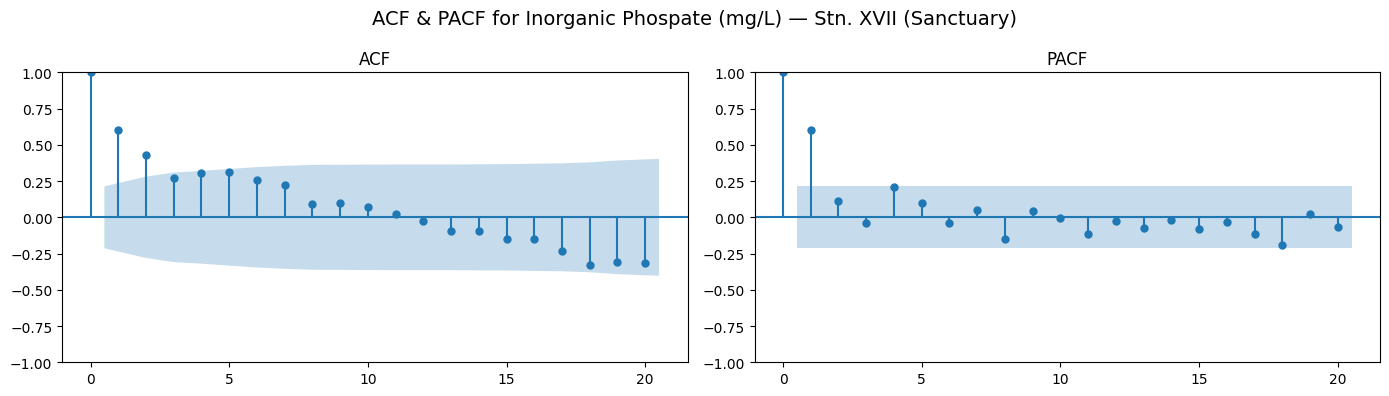

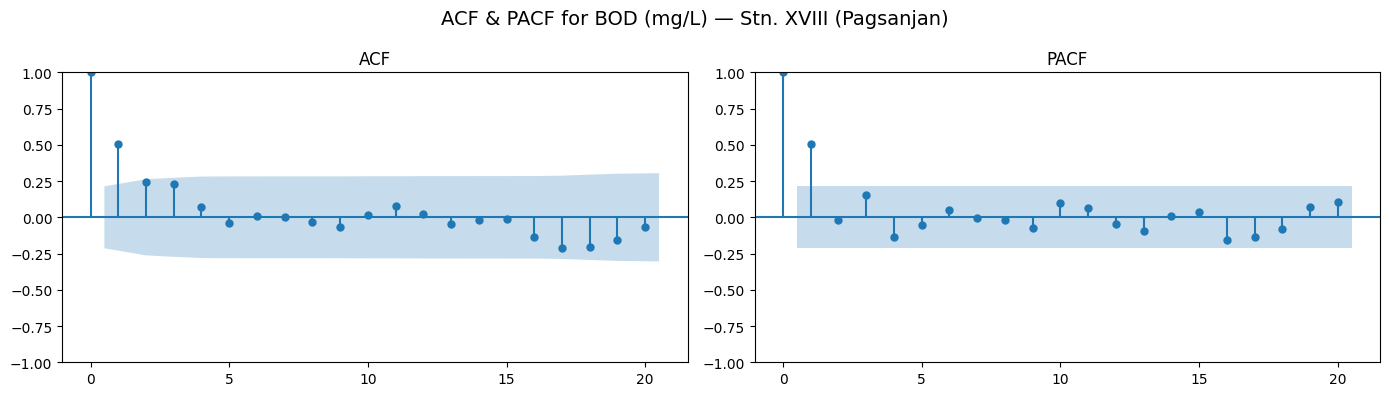

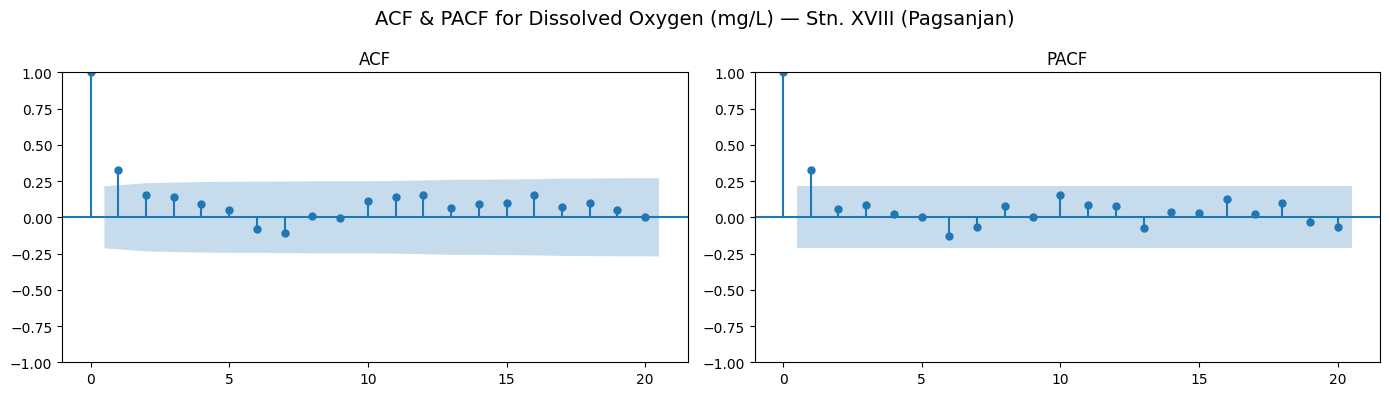

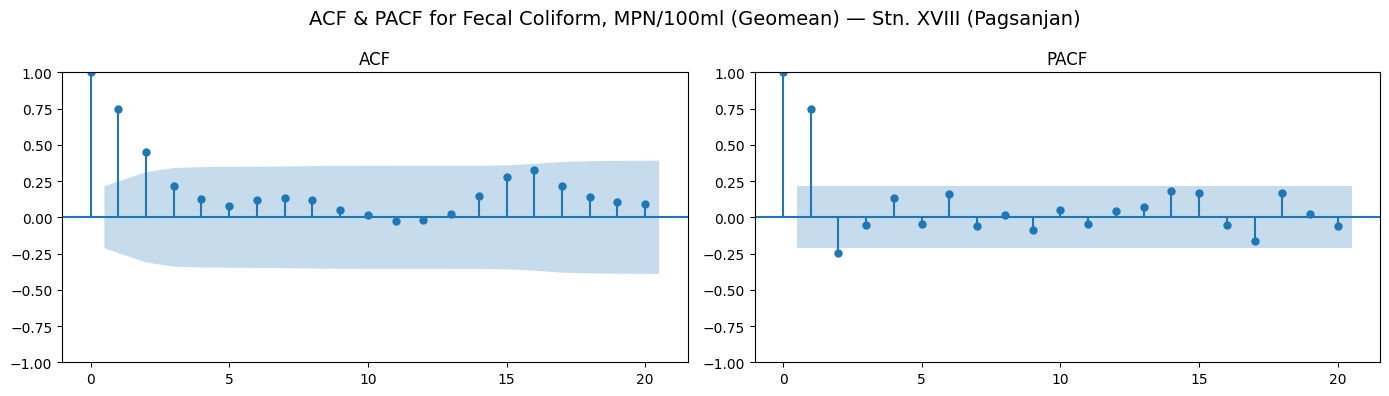

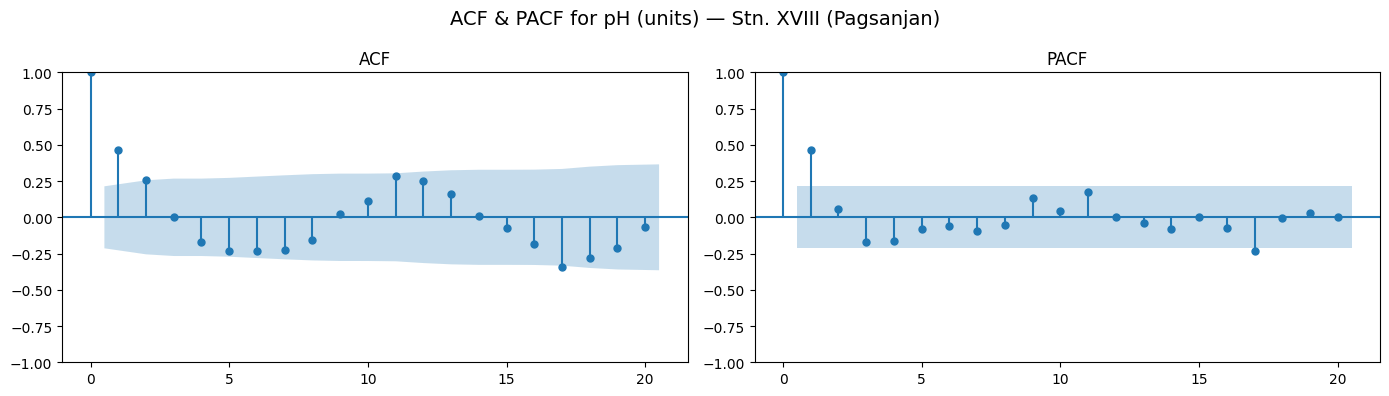

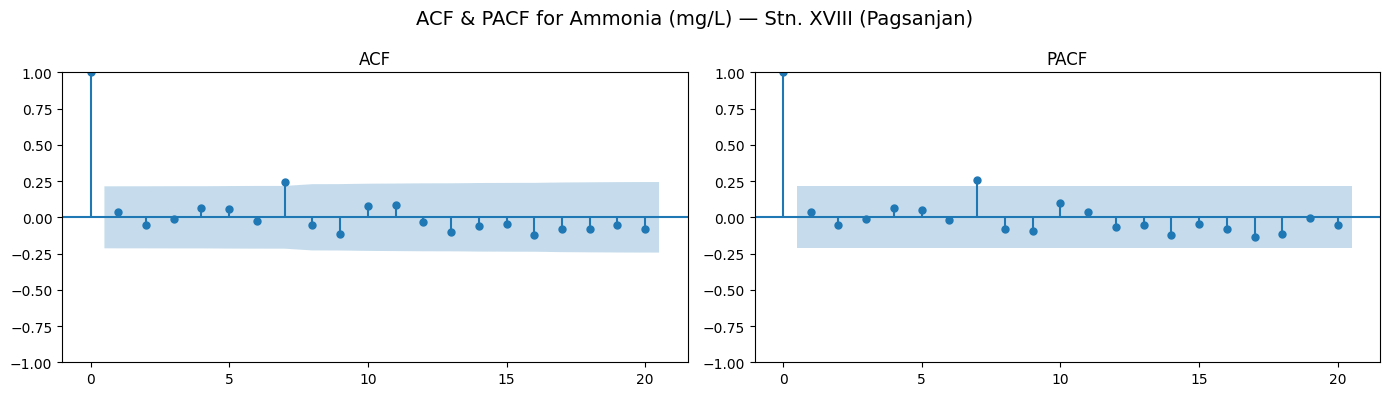

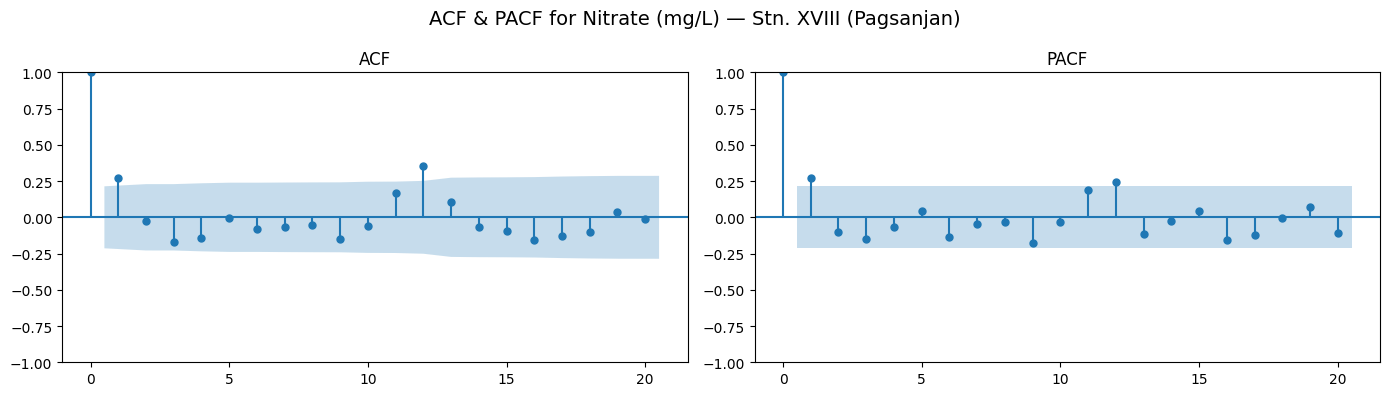

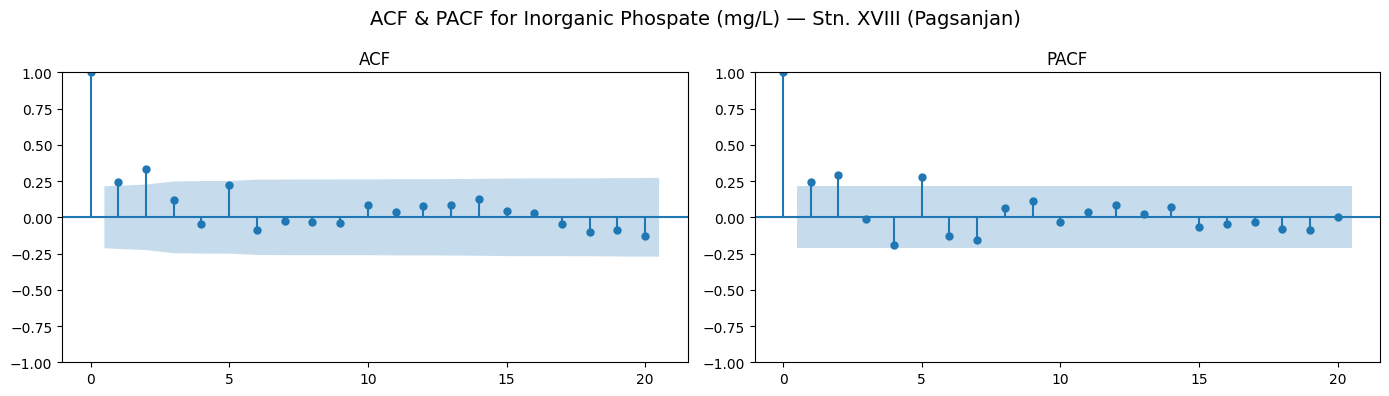

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

for station in stations:
    station_df = df[df['Stations'] == station].sort_values('Month')

    for param in parameters:
        series = station_df[param].dropna()

        # Create ACF and PACF plots
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        fig.suptitle(f"ACF & PACF for {param} — {station}", fontsize=14)

        plot_acf(series, ax=axes[0], lags=20)
        plot_pacf(series, ax=axes[1], lags=20)

        axes[0].set_title('ACF')
        axes[1].set_title('PACF')

        plt.tight_layout()
        plt.show()

In [6]:
## Test for ADF Stationarity

from statsmodels.tsa.stattools import adfuller

adf_results = []


for station in stations:
    station_df = df[df['Stations'] == station].sort_values('Month')

    for param in parameters:
        series = station_df[param].dropna()
        adf_result = adfuller(series)

        diff_p_value = None
        second_diff = None
        if adf_result[1] >= 0.05:
            diff_series = series.diff().dropna()
            adf_result_diff = adfuller(diff_series)
            diff_p_value = adf_result_diff[1]
        
        if diff_p_value:
            if diff_p_value >= 0.05:
                diff2_series = diff_series.diff().dropna()
                adf_result_diff2 = adfuller(diff2_series)
                second_diff = adf_result_diff2[1]

        adf_results.append({
            'Station': station,
            'Parameter': param,
            'ADF Statistic': adf_result[0],
            'p-value': adf_result[1],
            'Diffenced P-value': diff_p_value,
            '2-Differenced P-value': second_diff,
            'Lags Used': adf_result[2],
            'Number of Observations': adf_result[3]
        })


adf_df = pd.DataFrame(adf_results)
adf_df.to_csv('adf_results2.csv', index=False)

In [28]:
## separate csv files
import os
output_base = "separated_series"
os.makedirs(output_base, exist_ok=True)


for station in stations:
    safe_station = station.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "").replace("/", "-")
    station_folder = os.path.join(output_base, safe_station)
    os.makedirs(station_folder, exist_ok=True)

    station_df = df[df['Stations'] == station].sort_values('Month')

    for param in parameters:
        safe_param = param.replace(" ", "_").replace("/", "-").replace("(", "").replace(")", "")
        param_df = station_df[['Month', param]].dropna().reset_index(drop=True)
        param_df.columns = ['Month', 'Value']

        file_path = os.path.join(station_folder, f"{safe_param}.csv")
        param_df.to_csv(file_path, index=False)

In [46]:
## ARIMA Model
## So if differenced, then d is 1
## If not differenced, then d is 0
from statsmodels.tsa.arima.model import ARIMA

sI_ammonia_df = pd.read_csv("separated_series/Stn_I_Central_West_Bay/Ammonia_mg-L.csv")
sI_ammonia_df['Month'] = pd.to_datetime(sI_ammonia_df['Month'])

ammonia_series = sI_ammonia_df['Value'].reset_index(drop=True)

split_index = int(len(ammonia_series) * 0.8)
train_series = ammonia_series[:split_index]
test_series = ammonia_series[split_index:]

model = ARIMA(train_series, order=(2, 0, 0)) 
model_fit = model.fit()
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                   67
Model:                 ARIMA(2, 0, 0)   Log Likelihood                  82.886
Date:                Wed, 25 Jun 2025   AIC                           -157.772
Time:                        01:38:14   BIC                           -148.953
Sample:                             0   HQIC                          -154.282
                                 - 67                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0958      0.017      5.775      0.000       0.063       0.128
ar.L1          0.1545      0.141      1.097      0.273      -0.121       0.430
ar.L2          0.2031      0.119      1.713      0.0

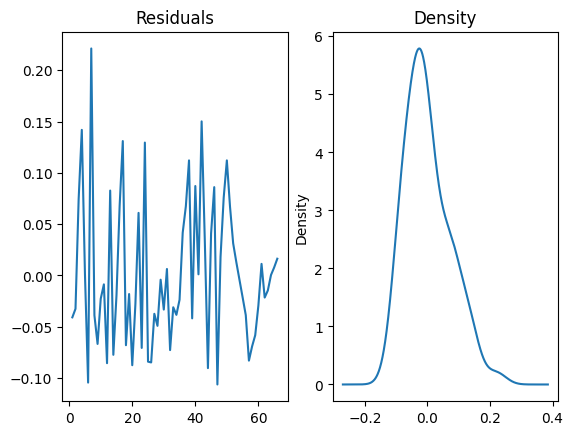

In [47]:
residuals = model_fit.resid[1:]
fig, ax = plt.subplots(1,2)
residuals.plot(title='Residuals', ax=ax[0])
residuals.plot(title='Density', kind='kde', ax=ax[1])
plt.show()

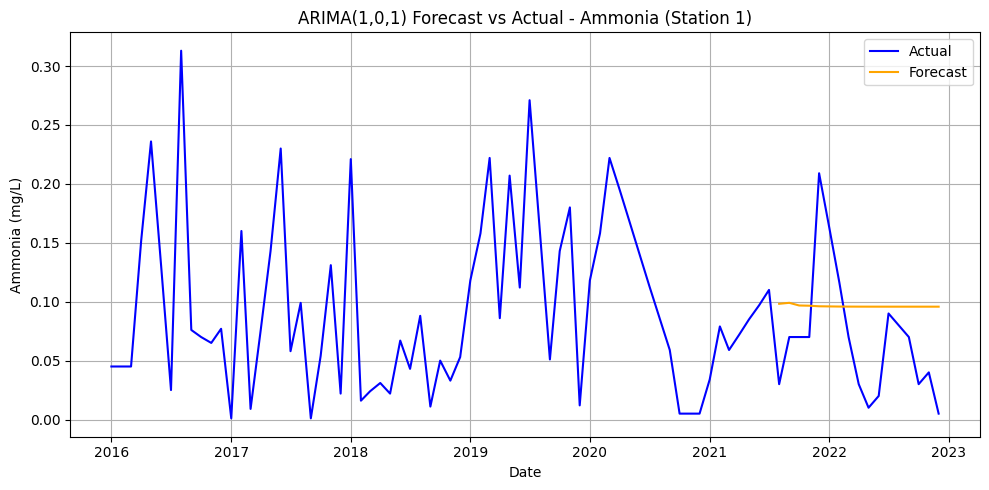

In [48]:
forecast = model_fit.forecast(len(test_series))

plot_df = sI_ammonia_df.copy()
plot_df['forecast_manual'] = np.nan
plot_df.loc[split_index:, 'forecast_manual'] = forecast.values

plt.figure(figsize=(10, 5))
plt.plot(plot_df['Month'], plot_df['Value'], label='Actual', color='blue')
plt.plot(plot_df['Month'], plot_df['forecast_manual'], label='Forecast', color='orange')
plt.title('ARIMA(1,0,1) Forecast vs Actual - Ammonia (Station 1)')
plt.xlabel('Date')
plt.ylabel('Ammonia (mg/L)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [56]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

mae = mean_absolute_error(test_series, forecast)
mape = mean_absolute_percentage_error(test_series, forecast)
rmse = np.sqrt(mean_squared_error(test_series, forecast))


print("Station 1 - Ammonia Forecasting Metrics")
print(f'mae - manual: {mae}')
print(f'mape - manual: {mape}')
print(f'rmse - manual: {rmse}')

Station 1 - Ammonia Forecasting Metrics
mae - manual: 0.05079375957223768
mape - manual: 2.4633226924410536
rmse - manual: 0.05905328704917901


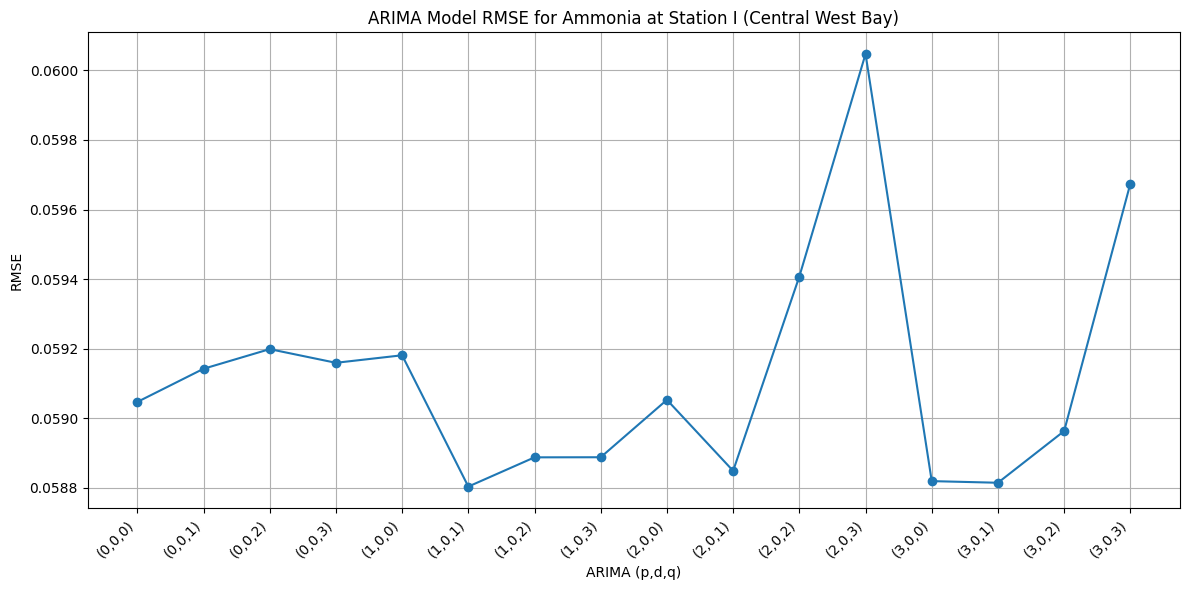

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the uploaded ARIMA metrics file
df = pd.read_csv("arima_gridsearch_metrics.csv")

# Filter for Station I (Central West Bay) and Ammonia (mg/L)
filtered_df = df[
    (df["Station"] == "Stn. I (Central West Bay)") &
    (df["Parameter"] == "Ammonia (mg/L)")
]

# Sort values by d, then p and q for better visualization
filtered_df = filtered_df.sort_values(by=["d", "p", "q"])

# Plot RMSE values for each (p,d,q) combination
plt.figure(figsize=(12, 6))
labels = [f"({p},{d},{q})" for p, d, q in zip(filtered_df['p'], filtered_df['d'], filtered_df['q'])]
plt.plot(labels, filtered_df["RMSE"], marker='o', linestyle='-')
plt.xticks(rotation=45, ha='right')
plt.xlabel("ARIMA (p,d,q)")
plt.ylabel("RMSE")
plt.title("ARIMA Model RMSE for Ammonia at Station I (Central West Bay)")
plt.tight_layout()
plt.grid(True)
plt.show()